# Interpretable Machine Learning for Earthquake Building Damage Assessment: Identifying Structural Factors Influencing Damage Severity



This notebook uses the Nepal earthquake **building structure dataset**. The required file is "csv_building_structure.csv"; a separate label file is not required because "damage_grade" is already present in the same table.


Run every cell from top to bottom. Output files are saved under `/kaggle/working`.


In [1]:

# 1. Reproducible setup and Kaggle paths

import os, sys, json, math, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
SEED= 42
random.seed(42)
np.random.seed(42)

WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd() / "working_outputs"
WORK_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR, TABLE_DIR = WORK_DIR / "figures", WORK_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "damage_grade"
ID_COLUMN = "building_id"
N_SPLITS = 5
TUNING_ITERATIONS = 15
EXPLANATION_SAMPLE_SIZE = 1500
PERMUTATION_REPEATS = 5
REQUEST_GPU = True
RUN_LOCATION_SENSITIVITY = True
RUN_LIGHTGBM = True
RUN_SHAP_INTERACTIONS = False

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})
print(f"Python: {sys.version.split()[0]}")
print(f"Working directory: {WORK_DIR}")


Python: 3.12.13
Working directory: /kaggle/working


In [2]:
# ============================================================
# 2. Imports and optional-library detection
# ============================================================
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, cohen_kappa_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import loguniform, spearmanr

try:
    import xgboost as xgb
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception as exc:
    HAS_XGBOOST = False
    print("XGBoost unavailable:", exc)
try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception as exc:
    HAS_CATBOOST = False
    print("CatBoost unavailable:", exc)
try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except Exception as exc:
    HAS_LIGHTGBM = False
    print("LightGBM unavailable:", exc)
try:
    import shap
    HAS_SHAP = True
except Exception as exc:
    HAS_SHAP = False
    print("SHAP unavailable:", exc)
try:
    import torch
    GPU_AVAILABLE = bool(torch.cuda.is_available())
except Exception:
    GPU_AVAILABLE = False
USE_GPU = bool(REQUEST_GPU and GPU_AVAILABLE)
print({"XGBoost": HAS_XGBOOST, "CatBoost": HAS_CATBOOST, "LightGBM": HAS_LIGHTGBM, "SHAP": HAS_SHAP, "GPU_used": USE_GPU})


{'XGBoost': True, 'CatBoost': True, 'LightGBM': True, 'SHAP': True, 'GPU_used': True}


In [3]:
# ============================================================
# 3. Find and load the building structure dataset
# ============================================================

import pandas as pd

DATA_PATH = "/kaggle/input/datasets/arashnic/earthquake-magnitude-damage-and-impact/csv_building_structure.csv"

data = pd.read_csv(DATA_PATH)


data.head()
print(f"Raw shape: {data.shape[0]:,} rows x {data.shape[1]} columns")
display(data.head())


Raw shape: 762,106 rows x 31 columns


,building_id,district_id,vdcmun_id,ward_id,count_floors_pre_eq,count_floors_post_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,height_ft_post_eq,...,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,condition_post_eq,damage_grade,technical_solution_proposed
0,120101000011,12,1207,120703,1,1,9,288,9,9,...,0,0,0,1,0,0,0,Damaged-Used in risk,Grade 3,Major repair
1,120101000021,12,1207,120703,1,1,15,364,9,9,...,0,0,0,1,0,0,0,Damaged-Repaired and used,Grade 5,Reconstruction
2,120101000031,12,1207,120703,1,1,20,384,9,9,...,0,0,0,0,0,0,0,Damaged-Repaired and used,Grade 2,Minor repair
3,120101000041,12,1207,120703,1,1,20,312,9,9,...,0,0,0,0,0,0,0,Damaged-Repaired and used,Grade 2,Minor repair
4,120101000051,12,1207,120703,1,1,30,308,9,9,...,0,0,0,0,0,0,0,Damaged-Repaired and used,Grade 1,Minor repair


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762106 entries, 0 to 762105
Data columns (total 31 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             762106 non-null  int64 
 1   district_id                             762106 non-null  int64 
 2   vdcmun_id                               762106 non-null  int64 
 3   ward_id                                 762106 non-null  int64 
 4   count_floors_pre_eq                     762106 non-null  int64 
 5   count_floors_post_eq                    762106 non-null  int64 
 6   age_building                            762106 non-null  int64 
 7   plinth_area_sq_ft                       762106 non-null  int64 
 8   height_ft_pre_eq                        762106 non-null  int64 
 9   height_ft_post_eq                       762106 non-null  int64 
 10  land_surface_condition                  762106 non-null 

In [5]:
data.describe()

,building_id,district_id,vdcmun_id,ward_id,count_floors_pre_eq,count_floors_post_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,height_ft_post_eq,...,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other
count,7.621060e+05,762106.000000,762106.000000,762106.000000,762106.000000,762106.000000,762106.000000,762106.000000,762106.000000,762106.000000,...,762106.000000,762106.000000,762106.000000,762106.000000,762106.000000,762106.000000,762106.000000,762106.000000,762106.000000,762106.000000
mean,2.607514e+11,25.767835,2582.688357,258274.277335,2.087783,1.252058,24.326405,406.672576,16.049372,9.868817,...,0.800271,0.035121,0.015815,0.022961,0.071525,0.258766,0.080482,0.039794,0.016386,0.012026
std,5.801855e+10,5.807555,581.172767,58117.348412,0.655101,1.063275,65.043704,226.779371,5.493878,8.574169,...,0.399797,0.184086,0.124761,0.149780,0.257701,0.437957,0.272039,0.195474,0.126955,0.109001
min,1.201010e+11,12.000000,1201.000000,120101.000000,1.000000,0.000000,0.000000,70.000000,6.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.219090e+11,22.000000,2204.000000,220402.000000,2.000000,0.000000,9.000000,280.000000,12.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.463020e+11,24.000000,2410.000000,241004.000000,2.000000,1.000000,16.000000,358.000000,16.000000,11.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.036080e+11,30.000000,3010.000000,301006.000000,2.000000,2.000000,27.000000,470.000000,18.000000,16.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,3.667090e+11,36.000000,3611.000000,361108.000000,9.000000,9.000000,999.000000,5000.000000,99.000000,99.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# *4. Data audit*
This cell performs data audit by examining column types, missing values, unique values, and duplicate records. It automatically identifies post-earthquake variables that may cause target leakage and marks them for exclusion from model training. Each feature is categorized as a predictor, target, identifier, or leakage variable to ensure proper dataset preparation.

In [6]:

# 4. Data audit and leakage audit
def post_event_columns(columns):
    detected = []
    for col in columns:
        lower = col.lower()
        if "post_eq" in lower or "post-earthquake" in lower or "post_earthquake" in lower:
            detected.append(col)
    detected.extend([c for c in ["condition_post_eq", "technical_solution_proposed"] if c in columns])
    return sorted(set(detected))

LEAKAGE_COLUMNS = post_event_columns(data.columns)
audit = pd.DataFrame({"column": data.columns, "dtype": data.dtypes.astype(str).values, "missing_n": data.isna().sum().values, "missing_percent": (data.isna().mean().values * 100).round(3), "unique_n": data.nunique(dropna=False).values})
audit["role"] = "candidate predictor"
audit.loc[audit["column"].eq(TARGET), "role"] = "target"
audit.loc[audit["column"].isin(LEAKAGE_COLUMNS), "role"] = "excluded post-event leakage"
audit.loc[audit["column"].eq(ID_COLUMN), "role"] = "identifier"
audit.to_csv(TABLE_DIR / "data_dictionary_and_audit.csv", index=False)
print("Detected post-event columns:", LEAKAGE_COLUMNS)
display(audit.sort_values(["role", "missing_percent"], ascending=[True, False]))
print(f"Exact duplicate rows: {data.duplicated().sum():,}")
print(f"Rows with missing target: {data[TARGET].isna().sum():,}")


Detected post-event columns: ['condition_post_eq', 'count_floors_post_eq', 'height_ft_post_eq', 'technical_solution_proposed']


,column,dtype,missing_n,missing_percent,unique_n,role
1,district_id,int64,0,0.000,11,candidate predictor
2,vdcmun_id,int64,0,0.000,110,candidate predictor
3,ward_id,int64,0,0.000,945,candidate predictor
4,count_floors_pre_eq,int64,0,0.000,9,candidate predictor
6,age_building,int64,0,0.000,176,candidate predictor
7,plinth_area_sq_ft,int64,0,0.000,2129,candidate predictor
8,height_ft_pre_eq,int64,0,0.000,79,candidate predictor
10,land_surface_condition,object,0,0.000,3,candidate predictor
11,foundation_type,object,0,0.000,5,candidate predictor
12,roof_type,object,0,0.000,3,candidate predictor


Exact duplicate rows: 0
Rows with missing target: 12


# *5. Data cleaning*
This cell cleans the dataset by removing duplicate records and rows with missing target values to ensure reliable model training. The target variable (damage grade) is transformed into numerical labels using Label Encoding, making it compatible with machine learning algorithms. It then calculates the frequency and percentage distribution of each damage class to assess potential class imbalance. Finally, the class distribution statistics are saved and displayed to support exploratory data analysis and model evaluation planning.

In [7]:

# 5. Clean records and define the target

data = data.dropna(subset=[TARGET]).drop_duplicates().reset_index(drop=True)
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(data[TARGET].astype(str))
CLASS_NAMES = list(target_encoder.classes_)
N_CLASSES = len(CLASS_NAMES)
target_counts = data[TARGET].astype(str).value_counts().rename_axis("damage_grade").reset_index(name="count")
target_counts["percent"] = target_counts["count"] / target_counts["count"].sum() * 100
target_counts.to_csv(TABLE_DIR / "target_class_distribution.csv", index=False)
print(f"Modeling rows: {len(data):,}; target classes: {CLASS_NAMES}")
display(target_counts)


Modeling rows: 762,094; target classes: ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4', 'Grade 5']


,damage_grade,count,percent
0,Grade 5,275766,36.185300
1,Grade 4,183844,24.123533
2,Grade 3,136412,17.899629
3,Grade 2,87257,11.449637
4,Grade 1,78815,10.341900


# **EDA**


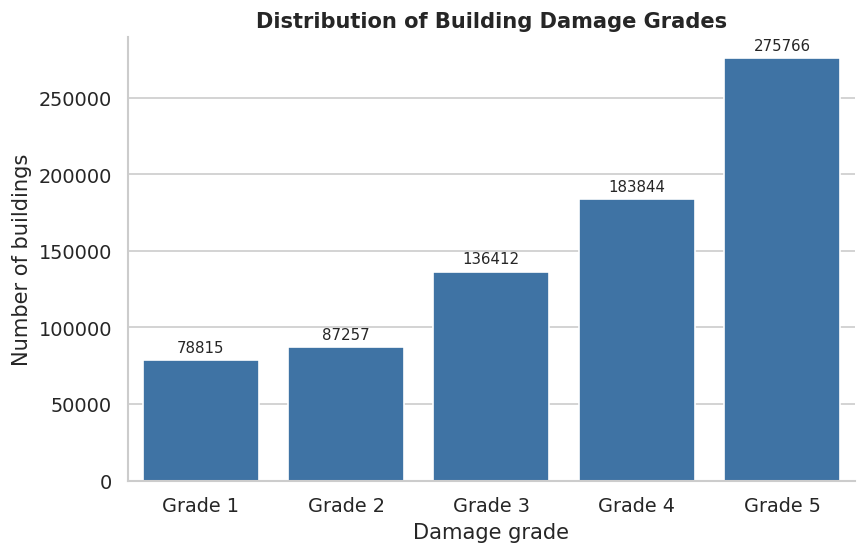

Saved figure: /kaggle/working/figures/fig01_damage_grade_distribution.png


*Figure note:* Class imbalance is reported before modeling because it affects metric selection and class weighting.

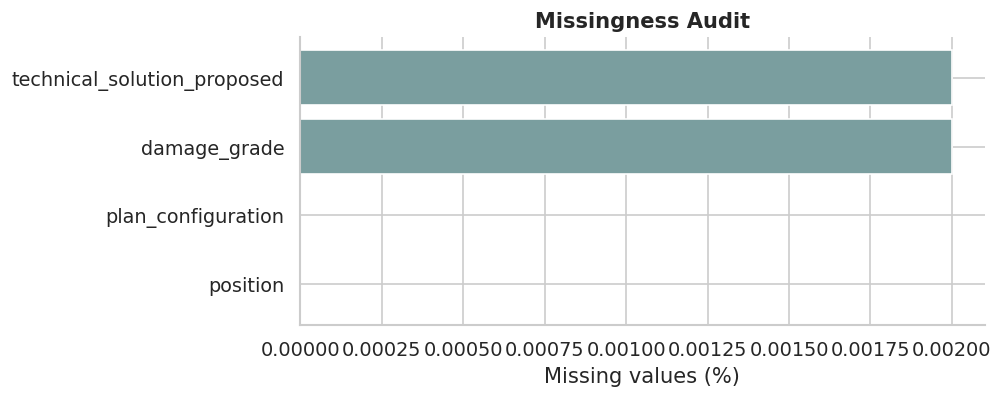

Saved figure: /kaggle/working/figures/fig02_missingness_audit.png


*Figure note:* Missing values are handled inside the modeling pipeline within each training fold.

In [8]:

# 6.Exploratory figures

def save_show(fig, filename, caption=None):
    fig.tight_layout()
    path = FIG_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {path}")
    if caption:
        display(Markdown(f"*Figure note:* {caption}"))

fig, ax = plt.subplots(figsize=(7.4, 4.8))
sns.countplot(data=data, x=TARGET, order=CLASS_NAMES, color="#2E74B5", ax=ax)
ax.set_title("Distribution of Building Damage Grades"); ax.set_xlabel("Damage grade"); ax.set_ylabel("Number of buildings")
for container in ax.containers: ax.bar_label(container, fmt="%d", padding=3, fontsize=9)
save_show(fig, "fig01_damage_grade_distribution.png", "Class imbalance is reported before modeling because it affects metric selection and class weighting.")

missing_plot = audit.loc[audit["missing_n"] > 0].sort_values("missing_percent", ascending=True)
fig, ax = plt.subplots(figsize=(8.5, max(3.5, 0.32 * len(missing_plot))))
if len(missing_plot):
    ax.barh(missing_plot["column"], missing_plot["missing_percent"], color="#7A9E9F"); ax.set_xlabel("Missing values (%)"); ax.set_title("Missingness Audit")
else:
    ax.text(0.5, 0.5, "No missing values detected", ha="center", va="center"); ax.set_axis_off()
save_show(fig, "fig02_missingness_audit.png", "Missing values are handled inside the modeling pipeline within each training fold.")


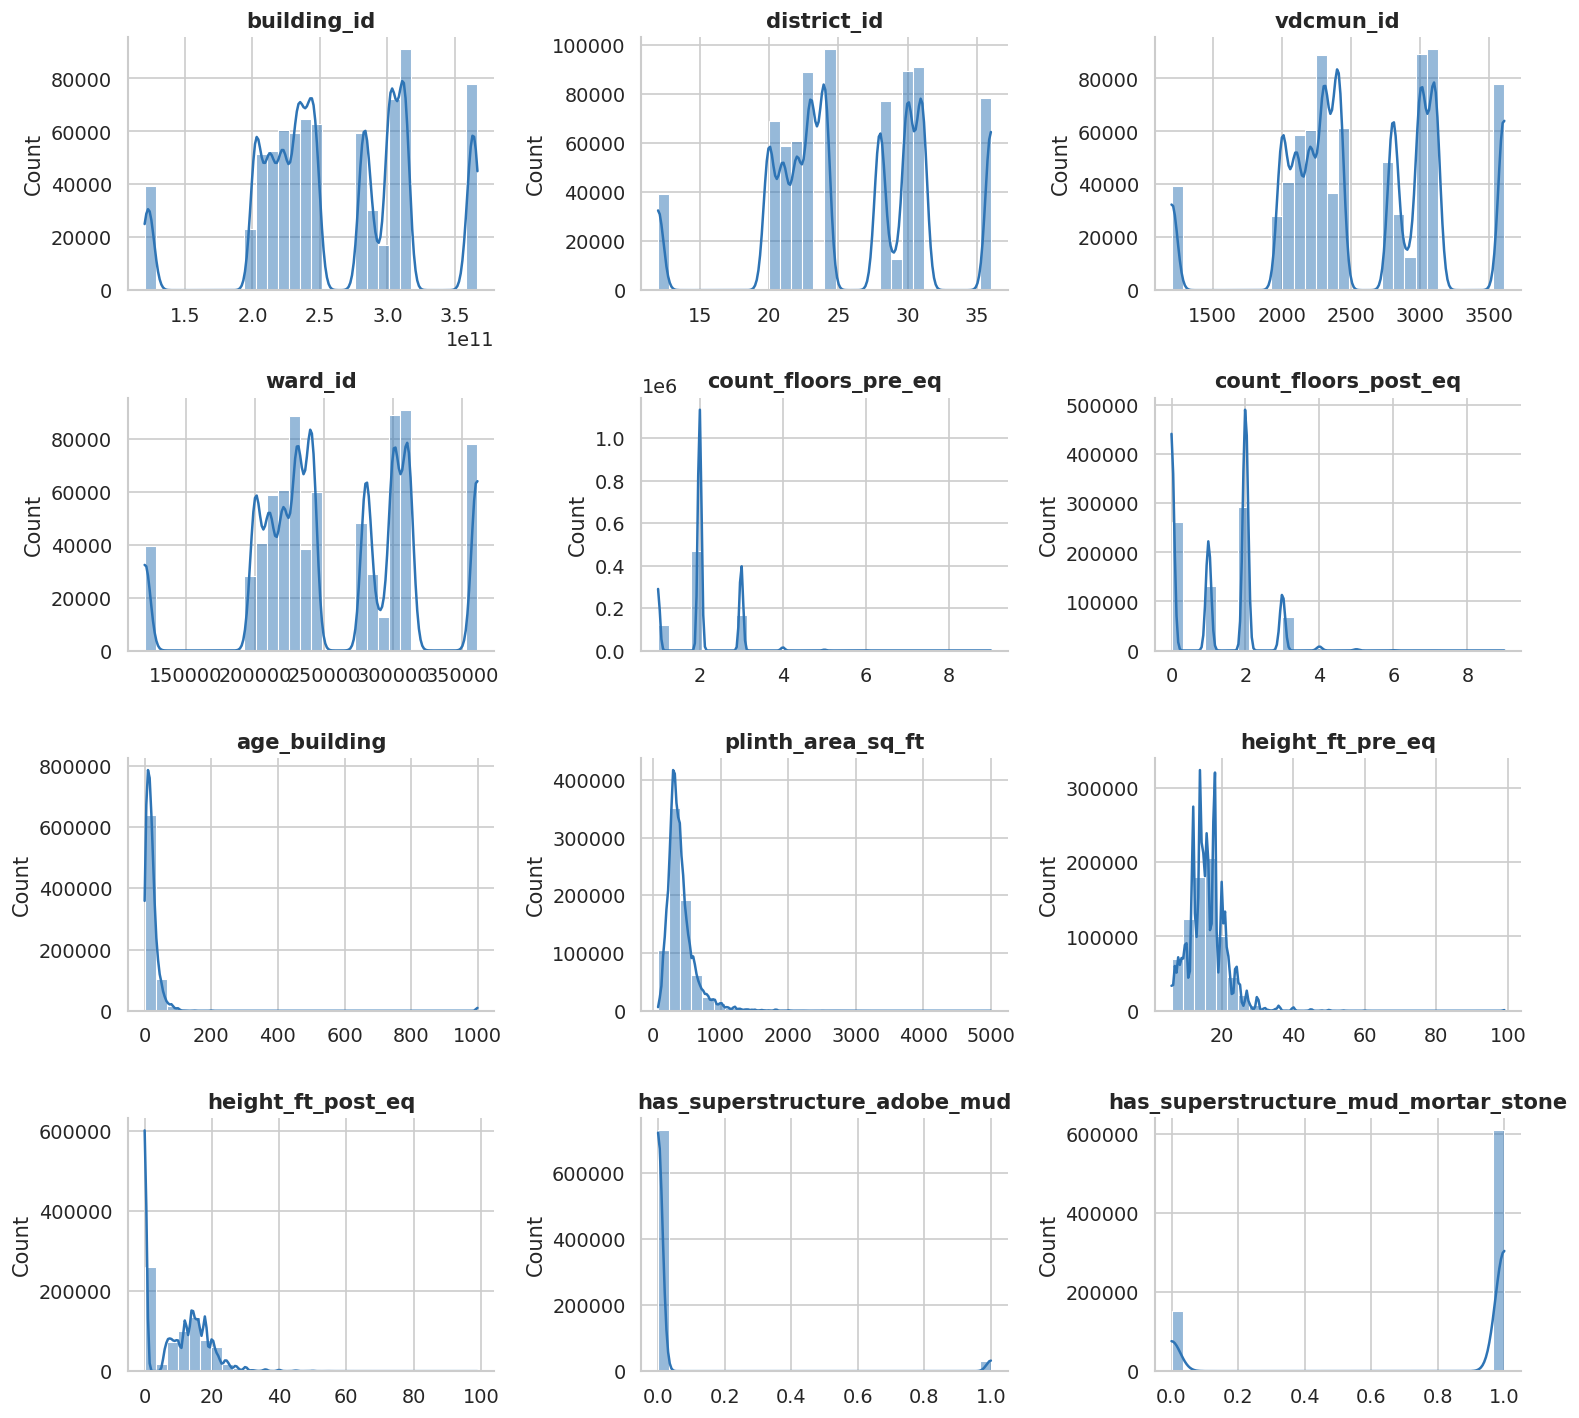

Saved figure: /kaggle/working/figures/fig03_numeric_feature_distributions.png


*Figure note:* Distributions show the range and skew of the main numeric predictors.

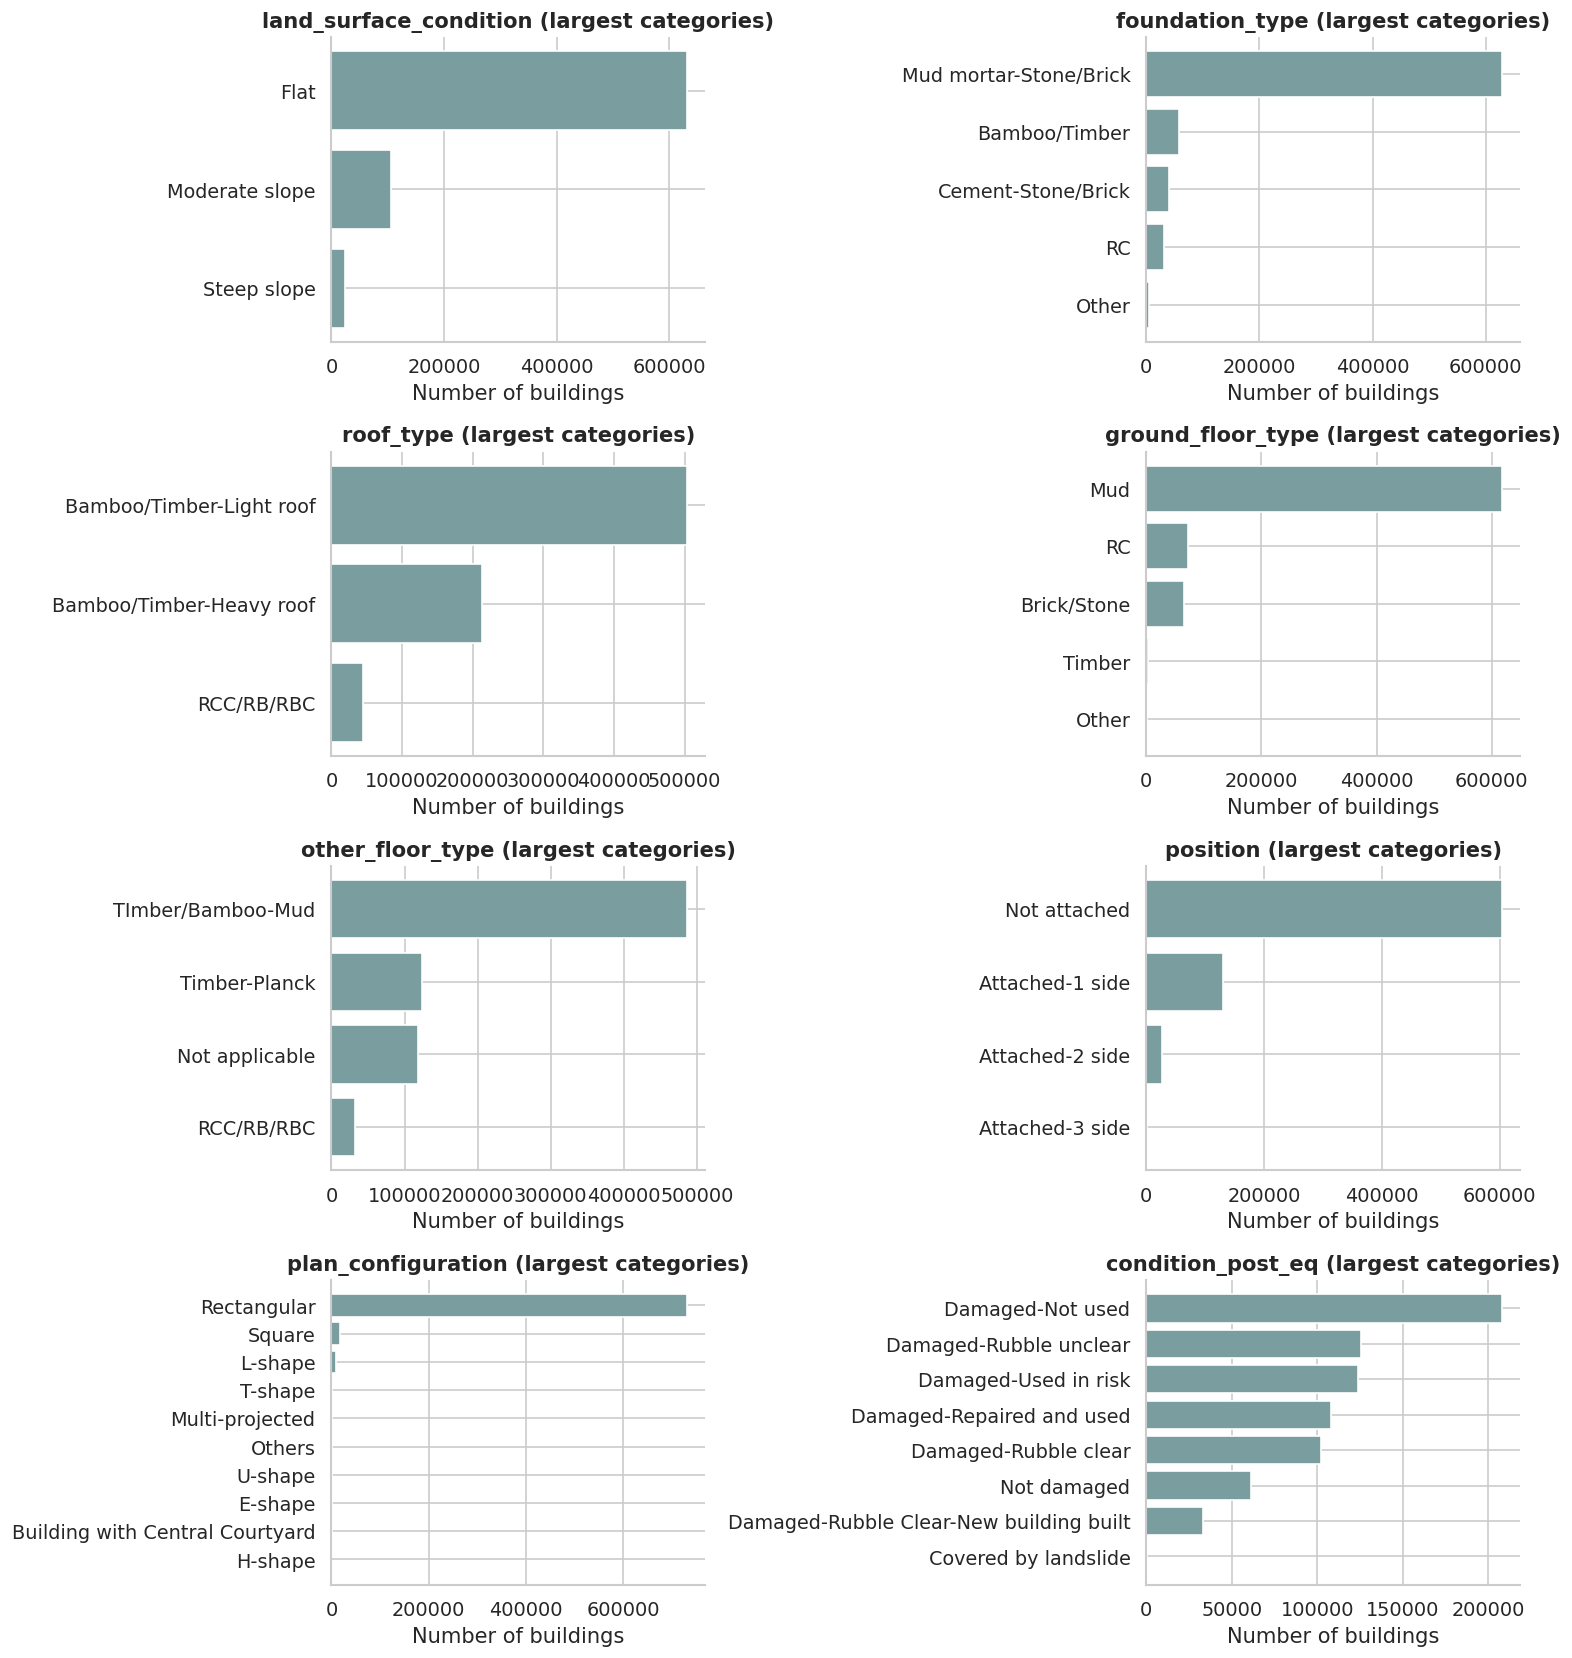

Saved figure: /kaggle/working/figures/fig04_categorical_feature_distributions.png


*Figure note:* The full category counts are available in the saved audit table.

In [9]:
# Figure 3: numerical distributions
numeric_cols_all = data.select_dtypes(include=np.number).columns.tolist()
numeric_plot_cols = [c for c in numeric_cols_all if c != TARGET][:12]
if numeric_plot_cols:
    ncols, nrows = 3, math.ceil(len(numeric_plot_cols) / 3)
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.0 * nrows)); axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, numeric_plot_cols):
        sns.histplot(data[col], bins=30, kde=True, color="#2E74B5", ax=ax); ax.set_title(col); ax.set_xlabel("")
    for ax in axes[len(numeric_plot_cols):]: ax.set_visible(False)
    save_show(fig, "fig03_numeric_feature_distributions.png", "Distributions show the range and skew of the main numeric predictors.")

# Figure 4: categorical distributions
categorical_cols_all = data.select_dtypes(include="object").columns.tolist()
categorical_plot_cols = [c for c in categorical_cols_all if c != TARGET][:8]
if categorical_plot_cols:
    ncols, nrows = 2, math.ceil(len(categorical_plot_cols) / 2)
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.5 * nrows)); axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, categorical_plot_cols):
        counts = data[col].astype(str).value_counts().head(12).sort_values()
        ax.barh(counts.index, counts.values, color="#7A9E9F"); ax.set_title(f"{col} (largest categories)"); ax.set_xlabel("Number of buildings")
    for ax in axes[len(categorical_plot_cols):]: ax.set_visible(False)
    save_show(fig, "fig04_categorical_feature_distributions.png", "The full category counts are available in the saved audit table.")


The numerical features show that most buildings have relatively small values, while a few buildings have very large values, creating skewed distributions. The plots also indicate that low-rise buildings and certain construction materials are much more common in the dataset than others. The categorical feature distributions show that a few categories dominate most variables, such as flat land surfaces, rectangular building plans, and mud-based construction materials. This indicates that certain building characteristics are much more common than others in the dataset.

# *Correlation*

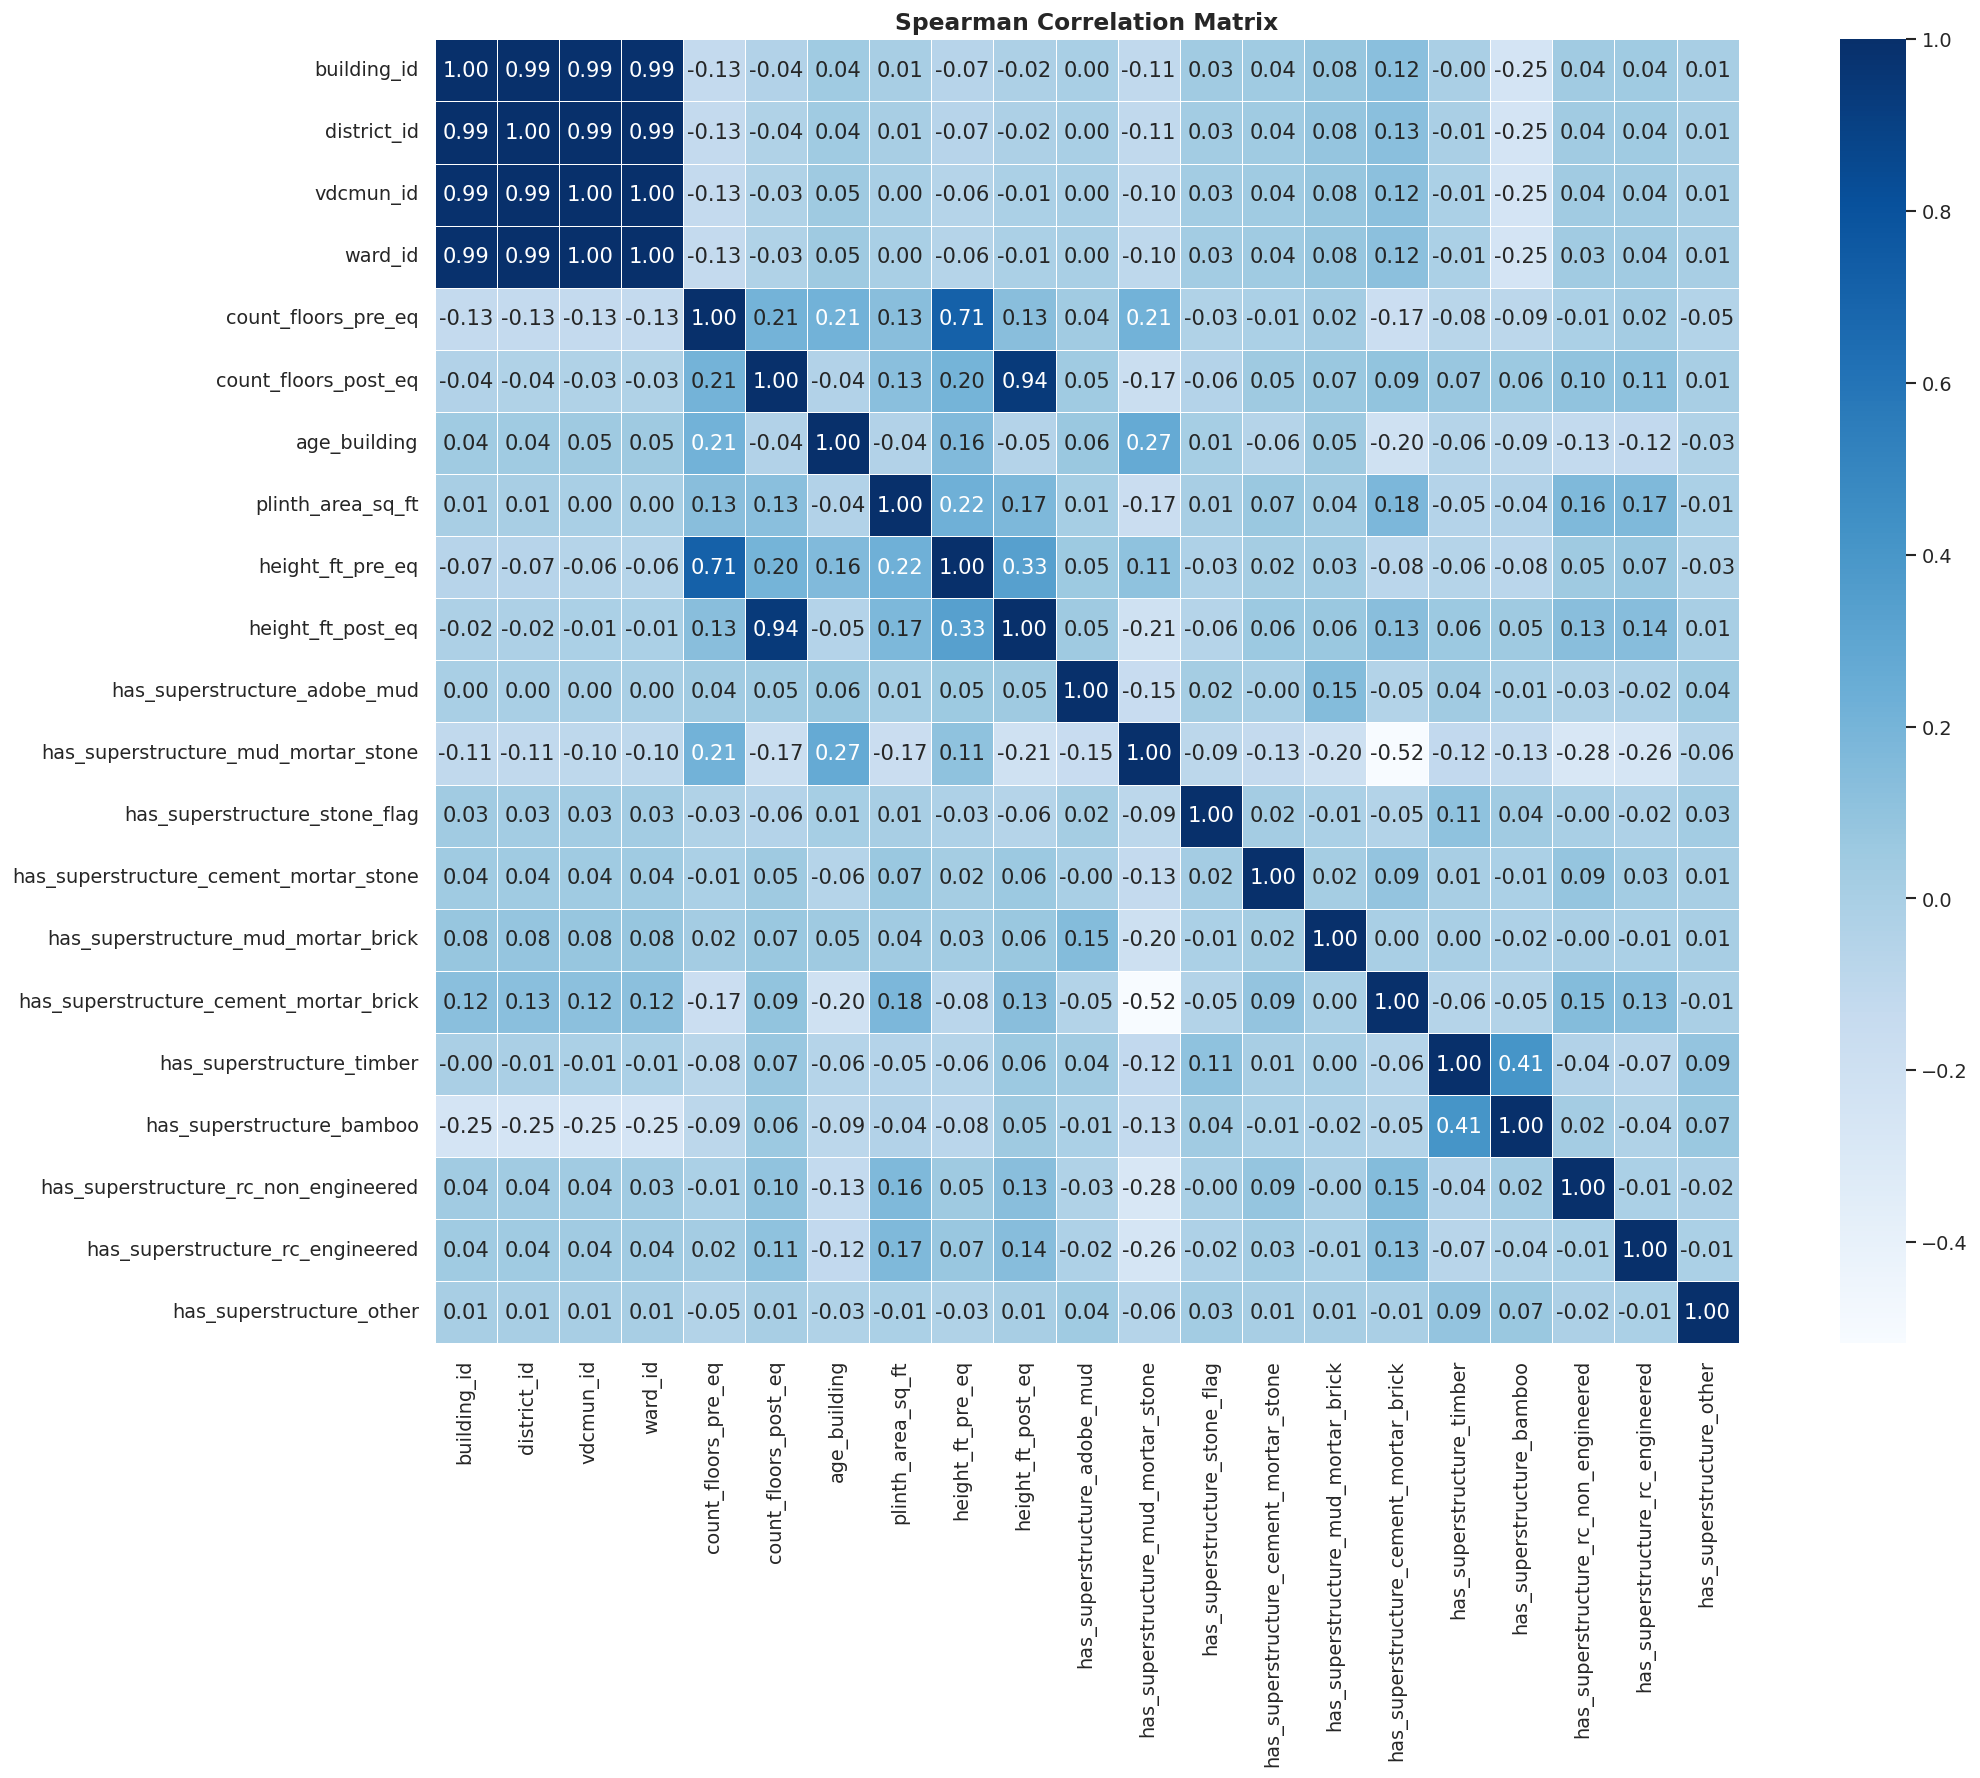

In [10]:
# Calculate the numerical correlation matrix
numerical_data = data.select_dtypes(include='number')
correlation_matrix = numerical_data.corr()
correlation_matrix
spearman_corr = data[numeric_cols_all].corr(method='spearman')

plt.figure(figsize=(20, 15))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap='Blues',
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Spearman Correlation Matrix", fontsize=14)

plt.tight_layout()

plt.show()

The Spearman numerical correlation matrix indicates that most predictor variables have weak correlations with one another, suggesting low multicollinearity and that each feature contributes distinct information. Strong positive correlations are observed between related structural attributes, such as count_floors_post_eq and height_ft_post_eq (0.94) and count_floors_pre_eq and height_ft_pre_eq (0.71), as taller buildings generally have more floors. The location identifiers (building_id, district_id, vdcmun_id, and ward_id) are also highly correlated because they represent hierarchical geographic information. Overall, the results suggest that the dataset contains a diverse set of features with limited redundancy, which is beneficial for predictive modeling.

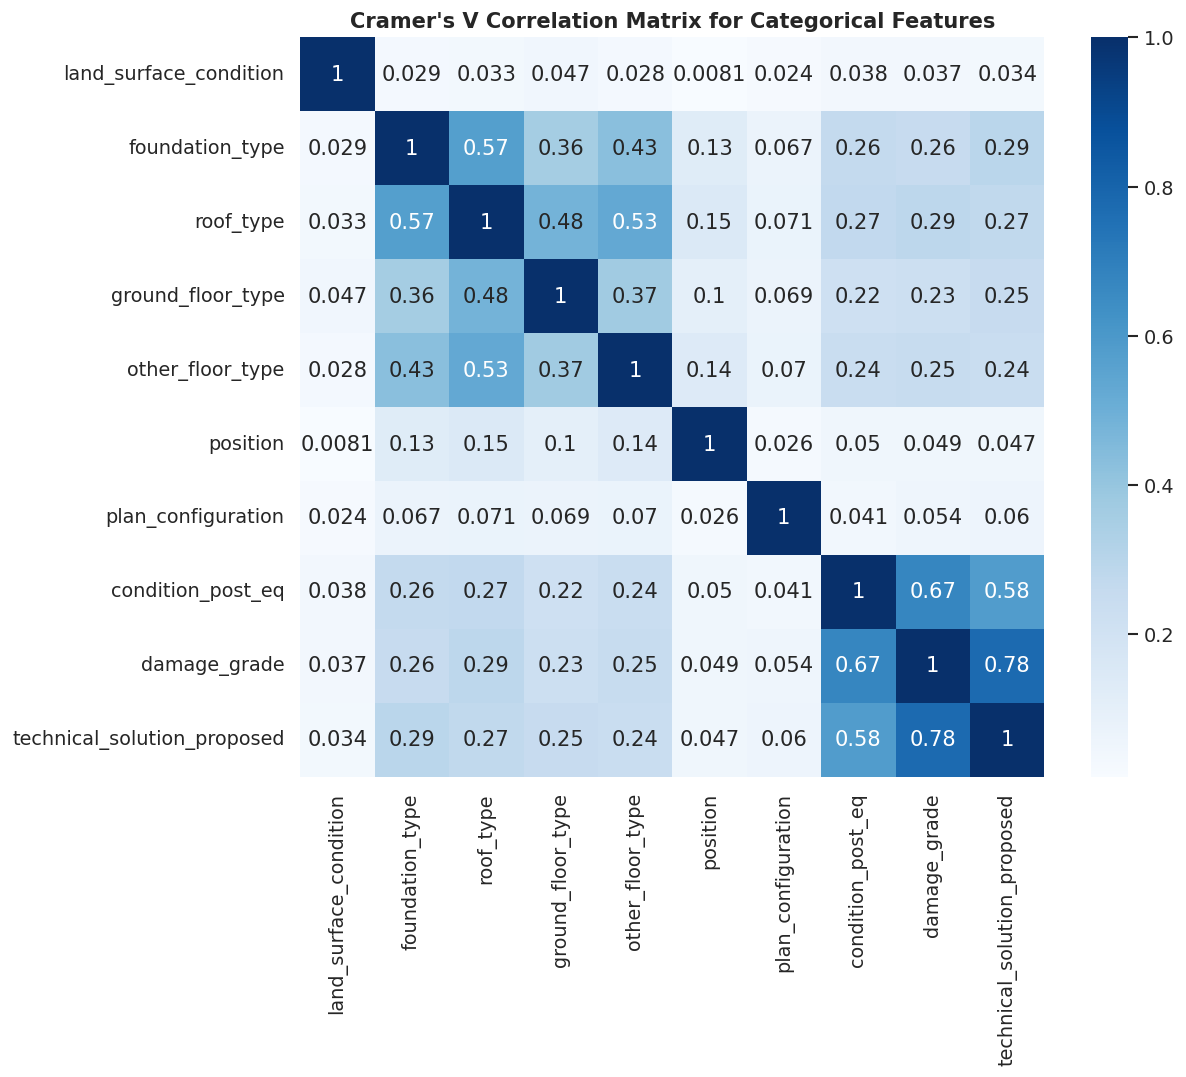

In [11]:
#categorical correlation
import scipy.stats as ss
import numpy as np


def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Calculate Cramer's V matrix
cramers_v_matrix = pd.DataFrame(
    [[cramers_v(data[col1], data[col2]) for col1 in categorical_cols_all] for col2 in categorical_cols_all],
    columns=categorical_cols_all, index=categorical_cols_all
)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix, annot=True, cmap='Blues')
plt.title('Cramer\'s V Correlation Matrix for Categorical Features')
plt.show()


The Cramer's V correlation matrix shows the strength of association between categorical variables. Strong relationships are observed among structural features such as foundation type, roof type, ground floor type, and other floor type (Cramer's V ≈ 0.36–0.57), indicating that construction materials and building components are closely related. The strongest associations involve damage_grade, particularly with condition_post_eq (0.67) and technical_solution_proposed (0.78), suggesting that post-earthquake building condition and proposed repair actions are highly dependent on the level of damage. In contrast, variables such as land_surface_condition, position, and plan_configuration exhibit weak associations with most other features, indicating that they provide relatively independent information.

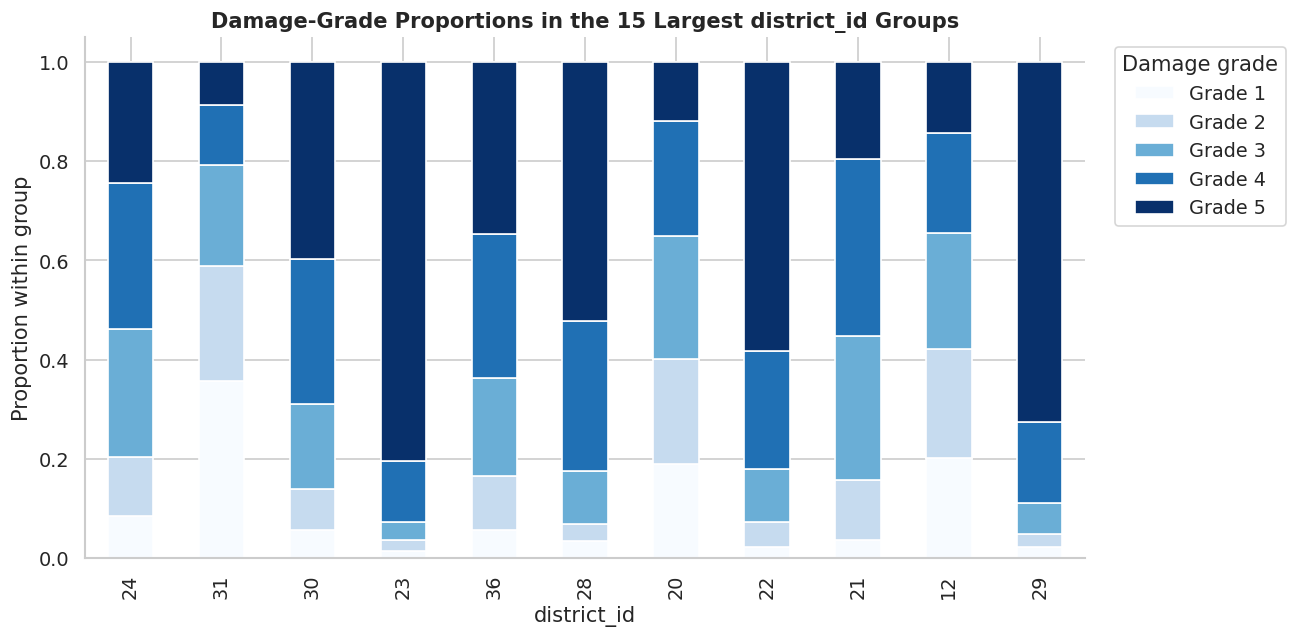

Saved figure: /kaggle/working/figures/fig05_damage_by_location.png


*Figure note:* Location patterns motivate grouped validation; they are not evidence that location alone causes damage.

Primary geographic grouping column: vdcmun_id; groups: 110


In [12]:
# Figure 5: damage-grade proportions by broad location
LOCATION_CANDIDATES = ["district_id", "vdcmun_id", "ward_id"]
LOCATION_COLUMNS = [column for column in LOCATION_CANDIDATES if column in data.columns]

GROUP_CANDIDATES = ["vdcmun_id", "ward_id", "district_id"]
GROUP_COLUMN = next((column for column in GROUP_CANDIDATES if column in data.columns), None)

if LOCATION_COLUMNS:
    broad_location = LOCATION_COLUMNS[0]
    largest_locations = data[broad_location].value_counts().head(15).index
    location_data = data[data[broad_location].isin(largest_locations)]

    location_table = pd.crosstab(
        location_data[broad_location].astype(str),
        location_data[TARGET].astype(str),
        normalize="index"
    )

    ordered_locations = [str(value) for value in largest_locations]
    location_table = location_table.reindex(ordered_locations).dropna(how="all")

    fig, ax = plt.subplots(figsize=(11, 5.5))
    location_table.reindex(columns=CLASS_NAMES, fill_value=0).plot(
        kind="bar",
        stacked=True,
        colormap="Blues",
        ax=ax
    )
    ax.set_title(f"Damage-Grade Proportions in the 15 Largest {broad_location} Groups")
    ax.set_xlabel(broad_location)
    ax.set_ylabel("Proportion within group")
    ax.legend(title="Damage grade", bbox_to_anchor=(1.02, 1), loc="upper left")
    save_show(
        fig,
        "fig05_damage_by_location.png",
        "Location patterns motivate grouped validation; they are not evidence that location alone causes damage."
    )

if GROUP_COLUMN is None:
    raise ValueError(
        "No geographic grouping column was found. Expected vdcmun_id, ward_id, or district_id."
    )

print(
    f"Primary geographic grouping column: {GROUP_COLUMN}; "
    f"groups: {data[GROUP_COLUMN].nunique(dropna=False):,}"
)


Figure 5 shows that the distribution of damage grades varies across the largest district groups, indicating geographic differences in earthquake impact. Some districts have a higher proportion of severe damage grades (Grades 4–5), while others contain relatively more moderate or low damage levels,

## Modeling design

The **structural + district** setting is the primary research result. It combines pre-earthquake construction characteristics with `district_id`, the coarsest available administrative location code, so the model can use broad geographic context (regional construction norms, climate/soil zone, distance-related effects) alongside structural vulnerability factors. Post-earthquake measurements are excluded because they would reveal information that would not be available before an earthquake.

Location is deliberately limited to `district_id` (11 categories) rather than the full `vdcmun_id`/`ward_id` hierarchy. Grouped cross-validation below holds out entire municipalities (`vdcmun_id`), and wards are nested inside municipalities, so both identifiers are guaranteed to be entirely unseen for any held-out geographic group and cannot generalize under this validation design — they would be encoded as "unknown" at test time no matter how informative they look during training. `district_id` is coarse enough (11 districts spread across 110 municipalities) that a held-out municipality's district is almost always still represented in the training folds, so it is the finest location signal that can be expected to generalize honestly.

Two additional settings are reported as ablation/sensitivity checks against the primary result: a **structural-only** setting with no location information at all, and a **structural-plus-full-location** setting that adds `vdcmun_id` and `ward_id` back in, to make explicit how little those finer codes contribute once geographic grouping is enforced. Neither replaces the primary structural + district result. All preprocessing is learned separately inside each training fold.


# **Feature Engineering**

New pre-earthquake structural features, such as average floor height, area per floor, slenderness ratio, and age per floor, are derived to capture additional building characteristics. It also defines three modeling scenarios like structural_only, structural_district, and structural_location to evaluate the contribution of geographic information while excluding identifiers and post-earthquake leakage variables. District-level location information is treated separately because it is sufficiently broad to generalize across unseen municipalities, whereas finer geographic variables (e.g., vdcmun_id and ward_id) may not generalize under grouped geographic validation. This scenario-based design enables a systematic assessment of whether earthquake damage prediction is driven primarily by structural attributes or by location-specific information.

In [13]:
# 7. Feature construction and scenarios

def add_pre_event_features(frame):
    X = frame.copy()
    if {"height_ft_pre_eq", "count_floors_pre_eq"}.issubset(X.columns):
        X["avg_floor_height_pre_eq"] = X["height_ft_pre_eq"] / X["count_floors_pre_eq"].replace(0, np.nan)
    if {"plinth_area_sq_ft", "count_floors_pre_eq"}.issubset(X.columns):
        X["area_per_floor_pre_eq"] = X["plinth_area_sq_ft"] / X["count_floors_pre_eq"].replace(0, np.nan)
    if {"height_ft_pre_eq", "plinth_area_sq_ft"}.issubset(X.columns):
        X["slenderness_proxy_pre_eq"] = X["height_ft_pre_eq"] / np.sqrt(X["plinth_area_sq_ft"].replace(0, np.nan))
    if {"age_building", "count_floors_pre_eq"}.issubset(X.columns):
        X["age_per_floor_pre_eq"] = X["age_building"] / X["count_floors_pre_eq"].replace(0, np.nan)
    return X.replace([np.inf, -np.inf], np.nan)

'''Only district_id is coarse enough (11 categories) to remain represented in training
once entire municipalities are held out by the grouped CV set up below; vdcmun_id is
the grouping column itself and ward_id is nested inside it, so both are guaranteed to
be unseen for any held-out geographic group and cannot generalize.'''
GENERALIZABLE_LOCATION_COLUMNS = [c for c in LOCATION_COLUMNS if c == "district_id"]
FINE_LOCATION_COLUMNS = [c for c in LOCATION_COLUMNS if c not in GENERALIZABLE_LOCATION_COLUMNS]

def make_scenario(name):
    drop = [TARGET, ID_COLUMN] + LEAKAGE_COLUMNS
    X = data.drop(columns=[c for c in drop if c in data.columns], errors="ignore").copy()
    if name == "structural_only":
        X = X.drop(columns=[c for c in LOCATION_COLUMNS if c in X.columns], errors="ignore")
    elif name == "structural_district":
        X = X.drop(columns=[c for c in FINE_LOCATION_COLUMNS if c in X.columns], errors="ignore")
    elif name != "structural_location":
        raise ValueError(f"Unknown scenario: {name}")
    X = add_pre_event_features(X)
    for col in LOCATION_COLUMNS:
        if col in X.columns: X[col] = X[col].astype("string")
    return X

SCENARIOS = ["structural_only", "structural_district"]
if RUN_LOCATION_SENSITIVITY and LOCATION_COLUMNS: SCENARIOS.append("structural_location")
scenario_features = {name: make_scenario(name) for name in SCENARIOS}
for name, X_scenario in scenario_features.items(): print(f"{name}: {X_scenario.shape[1]} predictors")


structural_only: 26 predictors
structural_district: 27 predictors
structural_location: 29 predictors


# **Preprocessing and Model**

Missing numerical values are replaced with median values, while missing categorical values are filled using the most frequent category. Categorical variables are then converted into one-hot encoding, and numerical features can be standardized when required by a model. The study evaluates multiple classification algorithms, including Logistic Regression, Random Forest, XGBoost, CatBoost, and LightGBM, using predefined hyperparameters and optional GPU acceleration. This standardized preprocessing and modeling framework ensures a fair and consistent comparison of predictive performance across all feature scenarios.

In [14]:
# 8. Preprocessing and model definitions

def make_one_hot_encoder():
    try: return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError: return OneHotEncoder(handle_unknown="ignore", sparse=True)

def make_preprocessor(X, scale_numeric=False):
    numeric = X.select_dtypes(include=np.number).columns.tolist()
    categorical = [c for c in X.columns if c not in numeric]
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric: numeric_steps.append(("scaler", StandardScaler(with_mean=False)))
    categorical_steps = [("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", make_one_hot_encoder())]
    transformers = []
    if numeric: transformers.append(("numeric", Pipeline(numeric_steps), numeric))
    if categorical: transformers.append(("categorical", Pipeline(categorical_steps), categorical))
    return ColumnTransformer(transformers=transformers, remainder="drop"), numeric, categorical

def xgb_parameters():
    params = dict(objective="multi:softprob", num_class=N_CLASSES, n_estimators=250, max_depth=6, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, min_child_weight=2, reg_lambda=1.0, eval_metric="mlogloss", random_state=42, n_jobs=-1, tree_method="hist")
    if USE_GPU:
        try: major = int(str(xgb.__version__).split(".")[0])
        except Exception: major = 0
        if major >= 2: params["device"] = "cuda"
        else: params["tree_method"] = "gpu_hist"
    return params

def make_model(name, params=None):
    params = params or {}
    if name == "Logistic Regression":
        base = dict(C=1.0, class_weight="balanced", max_iter=1500, solver="saga", n_jobs=-1, random_state=42); base.update(params); return LogisticRegression(**base)
    if name == "Random Forest":
        base = dict(n_estimators=300, max_depth=None, min_samples_leaf=2, max_features="sqrt", class_weight="balanced_subsample", n_jobs=-1, random_state=42); base.update(params); return RandomForestClassifier(**base)
    if name == "XGBoost":
        base = xgb_parameters(); base.update(params); return XGBClassifier(**base)
    if name == "CatBoost":
        base = dict(loss_function="MultiClass", iterations=300, depth=7, learning_rate=0.05, l2_leaf_reg=3.0, auto_class_weights="Balanced", random_seed=42, verbose=False, allow_writing_files=False)
        if USE_GPU: base.update(task_type="GPU", devices="0")
        base.update(params); return CatBoostClassifier(**base)
    if name == "LightGBM":
        base = dict(objective="multiclass", num_class=N_CLASSES, n_estimators=300, num_leaves=31, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, class_weight="balanced", random_state=42, n_jobs=-1, verbosity=-1); base.update(params); return LGBMClassifier(**base)
    raise ValueError(name)

MODEL_NAMES = ["Logistic Regression", "Random Forest"]
if HAS_XGBOOST: MODEL_NAMES.append("XGBoost")
if HAS_CATBOOST: MODEL_NAMES.append("CatBoost")
if RUN_LIGHTGBM and HAS_LIGHTGBM: MODEL_NAMES.append("LightGBM")
print("Models to benchmark:", MODEL_NAMES)


Models to benchmark: ['Logistic Regression', 'Random Forest', 'XGBoost', 'CatBoost', 'LightGBM']


A geographically aware train–test split is used to evaluate how well the model generalizes to unseen locations. Using Stratified Group K-Fold cross-validation, buildings belonging to the same geographic group (e.g.,  ward) are kept together, preventing information leakage between training and testing sets. The first fold is reserved as a final geographic test set, while the remaining data form the development set used for model training and validation.

In [15]:
# 9. Grouped development/test split

def make_group_cv(groups, preferred_splits=N_SPLITS):
    n_groups = int(pd.Series(groups).nunique())
    n_splits = min(preferred_splits, n_groups)
    if n_splits < 2: raise ValueError("At least two geographic groups are needed.")
    return StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

PRIMARY_SCENARIO = "structural_district"
X = scenario_features[PRIMARY_SCENARIO]
groups = data[GROUP_COLUMN].astype("string").fillna("__MISSING_GROUP__")
outer_cv = make_group_cv(groups, N_SPLITS)
outer_splits = list(outer_cv.split(X, y, groups))
dev_idx, final_test_idx = outer_splits[0]
X_dev, X_final_test = X.iloc[dev_idx].copy(), X.iloc[final_test_idx].copy()
y_dev, y_final_test = y[dev_idx], y[final_test_idx]
g_dev, g_final_test = groups.iloc[dev_idx], groups.iloc[final_test_idx]
print(f"Development rows: {len(dev_idx):,}; final geographic-test rows: {len(final_test_idx):,}")
print(f"Development groups: {g_dev.nunique():,}; final-test groups: {g_final_test.nunique():,}")
print("Geographic-group overlap:", len(set(g_dev) & set(g_final_test)))


Development rows: 614,499; final geographic-test rows: 147,595
Development groups: 87; final-test groups: 23
Geographic-group overlap: 0


This section benchmarks all selected models using grouped cross-validation, so buildings from the same geographic group do not appear in both training and validation folds. For each model and fold, the code fits the complete preprocessing–model pipeline, generates validation predictions, and calculates accuracy, balanced accuracy, macro precision/recall/F1, weighted F1, and quadratic weighted kappa; Macro F1 is emphasized because the damage classes are imbalanced. The code also includes a CPU fallback if XGBoost or CatBoost GPU training fails, then stores out-of-fold predictions and fold-level results. Finally, it calculates the mean and standard deviation across folds and ranks the models by mean Macro F1, with the results saved for later comparison.

In [16]:
# 10. Benchmark models with grouped cross-validation

SEED= 42
def as_1d_labels(predictions):
    """Normalize sklearn/XGBoost/CatBoost prediction shapes to (n_rows,)."""
    return np.asarray(predictions).reshape(-1).astype(int)

def metric_row(y_true, y_pred, model_name, fold, split_name="development_cv"):
    ''' Balanced accuracy (mean per-class recall) is reported alongside plain accuracy because
   of the class imbalance shown in fig01. Quadratic weighted kappa treats damage_grade as
   ordinal (Grade 1 < ... < Grade 5, which matches the label encoder's alphabetical order
    for this single-digit naming) and penalizes predictions further from the true grade more
    than near-miss ones, which macro/weighted F1 do not capture.'''
    return {
        "split": split_name, "model": model_name, "fold": fold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "quadratic_weighted_kappa": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
    }

dev_cv = make_group_cv(g_dev, N_SPLITS)
benchmark_rows, benchmark_oof = [], {}
for model_name in MODEL_NAMES:
    print(f"\nBenchmarking {model_name}")
    fold_predictions = np.full(len(dev_idx), -1, dtype=int)
    for fold, (tr_rel, va_rel) in enumerate(dev_cv.split(X_dev, y_dev, g_dev), start=1):
        X_tr, X_va, y_tr, y_va = X_dev.iloc[tr_rel], X_dev.iloc[va_rel], y_dev[tr_rel], y_dev[va_rel]
        preprocessor, _, _ = make_preprocessor(X_tr, scale_numeric=(model_name == "Logistic Regression"))
        pipe = Pipeline([("preprocessor", preprocessor), ("model", make_model(model_name))])
        try:
            pipe.fit(X_tr, y_tr)
        except Exception as exc:
            if model_name == "XGBoost" and USE_GPU:
                print("XGBoost GPU failed; retrying CPU:", str(exc)[:160]); cpu_model = make_model("XGBoost", {"tree_method": "hist"})
                pipe = Pipeline([("preprocessor", preprocessor), ("model", cpu_model)]); pipe.fit(X_tr, y_tr)
            elif model_name == "CatBoost" and USE_GPU:
                print("CatBoost GPU failed; retrying CPU:", str(exc)[:160]); cpu_model = make_model("CatBoost", {"task_type": "CPU"})
                pipe = Pipeline([("preprocessor", preprocessor), ("model", cpu_model)]); pipe.fit(X_tr, y_tr)
            else: raise
        y_va_pred = as_1d_labels(pipe.predict(X_va)); fold_predictions[va_rel] = y_va_pred
        benchmark_rows.append(metric_row(y_va, y_va_pred, model_name, fold))
        print(f"  fold {fold}: Macro F1 = {benchmark_rows[-1]['macro_f1']:.4f}")
    benchmark_oof[model_name] = fold_predictions

benchmark_fold_df = pd.DataFrame(benchmark_rows)
benchmark_fold_df.to_csv(TABLE_DIR / "model_benchmark_by_fold.csv", index=False)
benchmark_summary = benchmark_fold_df.groupby("model").agg({"accuracy": ["mean", "std"], "balanced_accuracy": ["mean", "std"], "macro_f1": ["mean", "std"], "weighted_f1": ["mean", "std"], "quadratic_weighted_kappa": ["mean", "std"]})
benchmark_summary.columns = ["_".join(c) for c in benchmark_summary.columns]
benchmark_summary = benchmark_summary.sort_values("macro_f1_mean", ascending=False).reset_index()
benchmark_summary.to_csv(TABLE_DIR / "model_benchmark_summary.csv", index=False)
display(benchmark_summary)



Benchmarking Logistic Regression
  fold 1: Macro F1 = 0.3944
  fold 2: Macro F1 = 0.4000
  fold 3: Macro F1 = 0.4139
  fold 4: Macro F1 = 0.3533
  fold 5: Macro F1 = 0.3922

Benchmarking Random Forest
  fold 1: Macro F1 = 0.3819
  fold 2: Macro F1 = 0.3937
  fold 3: Macro F1 = 0.4128
  fold 4: Macro F1 = 0.3617
  fold 5: Macro F1 = 0.3785

Benchmarking XGBoost
  fold 1: Macro F1 = 0.3839
  fold 2: Macro F1 = 0.3727
  fold 3: Macro F1 = 0.4070
  fold 4: Macro F1 = 0.3546
  fold 5: Macro F1 = 0.3718

Benchmarking CatBoost
  fold 1: Macro F1 = 0.4025
  fold 2: Macro F1 = 0.4041
  fold 3: Macro F1 = 0.4270
  fold 4: Macro F1 = 0.3753
  fold 5: Macro F1 = 0.3969

Benchmarking LightGBM
  fold 1: Macro F1 = 0.3937
  fold 2: Macro F1 = 0.4030
  fold 3: Macro F1 = 0.4254
  fold 4: Macro F1 = 0.3729
  fold 5: Macro F1 = 0.3962


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,quadratic_weighted_kappa_mean,quadratic_weighted_kappa_std
0,CatBoost,0.439118,0.044035,0.417660,0.022835,0.401171,0.018472,0.438025,0.042495,0.606990,0.079687
1,LightGBM,0.436482,0.046431,0.415522,0.023331,0.398252,0.018869,0.435095,0.044330,0.600635,0.082059
2,Logistic Regression,0.432922,0.048278,0.409071,0.026499,0.390767,0.022576,0.428249,0.044207,0.595896,0.089750
3,Random Forest,0.431326,0.044298,0.400037,0.020708,0.385715,0.018996,0.427044,0.043920,0.582921,0.083568
4,XGBoost,0.467229,0.049147,0.401266,0.019136,0.377997,0.019299,0.428503,0.048528,0.601477,0.091631


CatBoost achieved the best overall performance, obtaining the highest Macro F1 (0.401), Balanced Accuracy (0.418), Weighted F1 (0.438), and Quadratic Weighted Kappa (0.607) among all evaluated models. Since Macro F1 treats all damage grades equally regardless of class frequency, this indicates that CatBoost provides the most balanced classification performance across both majority and minority damage classes. Although XGBoost achieved the highest overall accuracy (0.467), it recorded the lowest Macro F1 score (0.378). This indicates that the model was more successful at predicting dominant classes but less effective at identifying minority damage grades. Therefore, accuracy alone would overestimate its practical performance for this imbalanced multiclass problem.

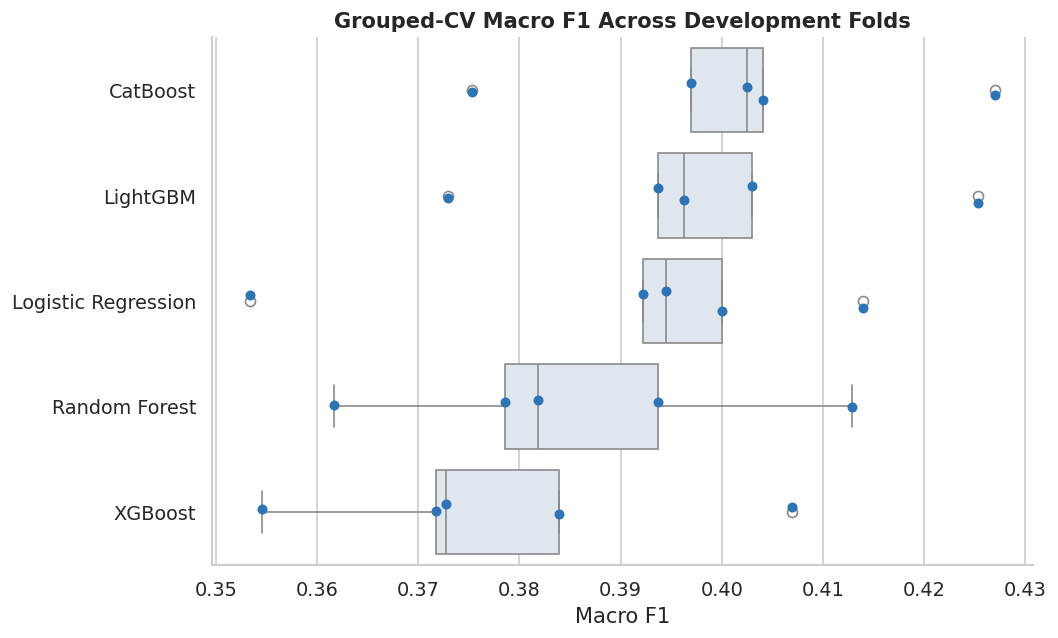

Saved figure: /kaggle/working/figures/fig06_grouped_cv_model_comparison.png


*Figure note:* Models are compared using geographic folds; variation across folds is reported as a stability measure.

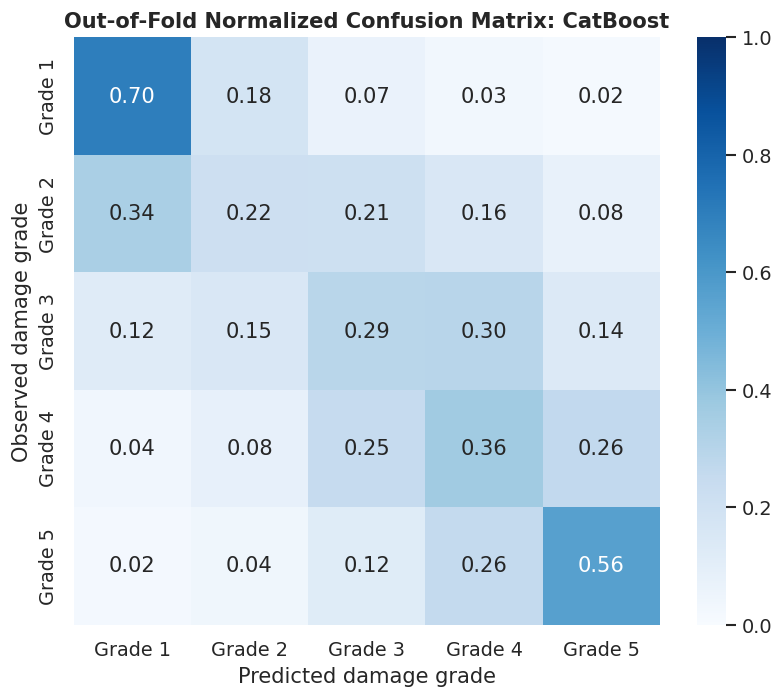

Saved figure: /kaggle/working/figures/fig07_best_benchmark_oof_confusion_matrix.png


*Figure note:* Rows are normalized so recall patterns for all damage grades can be compared.

In [17]:
# 11. Benchmark figures and confusion matrix

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=benchmark_fold_df, x="macro_f1", y="model", order=benchmark_summary["model"], color="#DCE6F1", ax=ax)
sns.stripplot(data=benchmark_fold_df, x="macro_f1", y="model", order=benchmark_summary["model"], color="#2E74B5", size=6, ax=ax)
ax.set_title("Grouped-CV Macro F1 Across Development Folds"); ax.set_xlabel("Macro F1"); ax.set_ylabel("")
save_show(fig, "fig06_grouped_cv_model_comparison.png", "Models are compared using geographic folds; variation across folds is reported as a stability measure.")

best_benchmark_model = benchmark_summary.iloc[0]["model"]
best_oof = benchmark_oof[best_benchmark_model]; oof_valid = best_oof >= 0
cm = confusion_matrix(y_dev[oof_valid], best_oof[oof_valid], labels=np.arange(N_CLASSES), normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f"Out-of-Fold Normalized Confusion Matrix: {best_benchmark_model}"); ax.set_xlabel("Predicted damage grade"); ax.set_ylabel("Observed damage grade")
save_show(fig, "fig07_best_benchmark_oof_confusion_matrix.png", "Rows are normalized so recall patterns for all damage grades can be compared.")


The normalized confusion matrix shows that CatBoost performs best when predicting the extreme damage categories. Grade 1 is correctly classified in 70% of cases, while Grade 5 achieves 56% correct classification. However, the model struggles to distinguish between the intermediate damage levels (Grades 2–4), where substantial misclassification occurs between adjacent classes. For example, Grade 3 is frequently confused with Grade 4, and Grade 4 is often predicted as Grade 5. This pattern suggests that buildings with moderate damage share similar structural characteristics, making them more difficult to separate. Importantly, most errors occur between neighboring damage grades rather than between extreme categories, indicating that the model generally captures the ordinal progression of earthquake damage severity.

## Hyperparameter tuning

The two strongest models from grouped development cross-validation are tuned on the development data only. The final geographic test fold remains untouched until final evaluation.

In [18]:

# 12. Tune the best two models with grouped CV

selected_models = benchmark_summary["model"].head(2).tolist()
print("Selected for tuning:", selected_models)
PARAM_DISTRIBUTIONS = {
    "Logistic Regression": {"model__C": loguniform(1e-3, 10)},
    "Random Forest": {"model__n_estimators": [250, 400, 600], "model__max_depth": [None, 12, 20, 30], "model__min_samples_leaf": [1, 2, 5, 10], "model__max_features": ["sqrt", "log2", 0.5]},
    "XGBoost": {"model__n_estimators": [200, 300, 450, 600], "model__max_depth": [3, 5, 7, 9], "model__learning_rate": [0.02, 0.04, 0.07, 0.1], "model__min_child_weight": [1, 3, 7], "model__subsample": [0.7, 0.85, 1.0], "model__colsample_bytree": [0.7, 0.85, 1.0]},
    "CatBoost": {"model__iterations": [250, 400, 600], "model__depth": [5, 6, 7, 8, 10], "model__learning_rate": [0.02, 0.04, 0.07, 0.1], "model__l2_leaf_reg": [1, 3, 5, 10]},
    "LightGBM": {"model__n_estimators": [200, 350, 500], "model__num_leaves": [15, 31, 63], "model__max_depth": [-1, 8, 15], "model__learning_rate": [0.02, 0.04, 0.07, 0.1], "model__min_child_samples": [10, 20, 40]},
}

tune_cv = make_group_cv(g_dev, N_SPLITS)
tuned_searches, tuning_rows = {}, []
for model_name in selected_models:
    preprocessor, _, _ = make_preprocessor(X_dev, scale_numeric=(model_name == "Logistic Regression"))
    pipe = Pipeline([("preprocessor", preprocessor), ("model", make_model(model_name))])
    search = RandomizedSearchCV(pipe, PARAM_DISTRIBUTIONS[model_name], n_iter=TUNING_ITERATIONS, scoring="f1_macro", cv=tune_cv, random_state=42, refit=True, n_jobs=1, verbose=1, return_train_score=False)
    print(f"\nTuning {model_name}")
    try:
        search.fit(X_dev, y_dev, groups=g_dev)
    except Exception as exc:
        if model_name in {"XGBoost", "CatBoost"} and USE_GPU:
            print("GPU tuning failed; retrying CPU:", str(exc)[:180])
            cpu_params = {"task_type": "CPU"} if model_name == "CatBoost" else {"tree_method": "hist"}
            pipe = Pipeline([("preprocessor", preprocessor), ("model", make_model(model_name, cpu_params))])
            search = RandomizedSearchCV(pipe, PARAM_DISTRIBUTIONS[model_name], n_iter=TUNING_ITERATIONS, scoring="f1_macro", cv=tune_cv, random_state=42, refit=True, n_jobs=1, verbose=1, return_train_score=False)
            search.fit(X_dev, y_dev, groups=g_dev)
        else: raise
    tuned_searches[model_name] = search
    tuning_rows.append({"model": model_name, "best_cv_macro_f1": search.best_score_, "best_params": json.dumps(search.best_params_, default=str)})
tuning_summary = pd.DataFrame(tuning_rows).sort_values("best_cv_macro_f1", ascending=False)
tuning_summary.to_csv(TABLE_DIR / "tuning_summary.csv", index=False)
display(tuning_summary)


Selected for tuning: ['CatBoost', 'LightGBM']

Tuning CatBoost
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Tuning LightGBM
Fitting 5 folds for each of 15 candidates, totalling 75 fits


,model,best_cv_macro_f1,best_params
0,CatBoost,0.402420,"{""model__learning_rate"": 0.02, ""model__l2_leaf..."
1,LightGBM,0.400149,"{""model__num_leaves"": 15, ""model__n_estimators..."


After identifying CatBoost and LightGBM as the two strongest benchmark models, hyperparameter optimization was performed using RandomizedSearchCV with grouped cross-validation. Multiple combinations of model parameters, including tree depth, learning rate, ensemble size, and regularization settings, were evaluated. Macro F1 score was used as the optimization objective because it provides balanced evaluation across all damage grades. The best-performing parameter configurations were selected based on their average grouped cross-validation Macro F1 score and were used for subsequent final evaluation.

,split,model,fold,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,quadratic_weighted_kappa,macro_ovr_roc_auc
0,final_geographic_test,CatBoost,0,0.462814,0.406427,0.402781,0.406427,0.399781,0.461936,0.586487,0.751803
1,final_geographic_test,LightGBM,0,0.447752,0.402447,0.388178,0.402447,0.390068,0.449987,0.561150,0.749156


,precision,recall,f1-score,support
Grade 1,0.414150,0.463183,0.437296,12019.000000
Grade 2,0.223677,0.280341,0.248824,16883.000000
Grade 3,0.320906,0.193663,0.241552,25911.000000
Grade 4,0.364539,0.438395,0.398070,36328.000000
Grade 5,0.690635,0.656552,0.673162,56454.000000
accuracy,0.462814,0.462814,0.462814,0.462814
macro avg,0.402781,0.406427,0.399781,147595.000000
weighted avg,0.469535,0.462814,0.461936,147595.000000


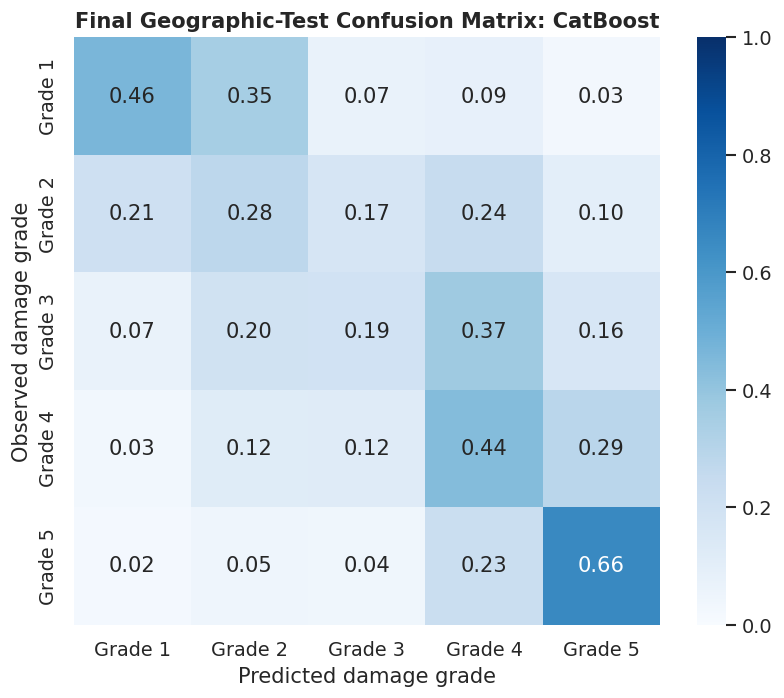

Saved figure: /kaggle/working/figures/fig08_final_geographic_test_confusion_matrix.png


*Figure note:* This is the untouched geographic test fold reserved before tuning.

In [19]:
# 13. Final geographic-test evaluation
best_tuned_model_name = tuning_summary.iloc[0]["model"]
best_search = tuned_searches[best_tuned_model_name]
best_pipeline = best_search.best_estimator_
final_rows, final_predictions = [], {}
for model_name, search in tuned_searches.items():
    pipe = search.best_estimator_; pred = as_1d_labels(pipe.predict(X_final_test)); final_predictions[model_name] = pred
    row = metric_row(y_final_test, pred, model_name, fold=0, split_name="final_geographic_test")
    try: row["macro_ovr_roc_auc"] = roc_auc_score(y_final_test, pipe.predict_proba(X_final_test), multi_class="ovr", average="macro")
    except Exception: row["macro_ovr_roc_auc"] = np.nan
    final_rows.append(row)
final_metrics = pd.DataFrame(final_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
final_metrics.to_csv(TABLE_DIR / "final_geographic_test_metrics.csv", index=False)
display(final_metrics)

best_final_pred = final_predictions[best_tuned_model_name]
report = pd.DataFrame(classification_report(y_final_test, best_final_pred, labels=np.arange(N_CLASSES), target_names=CLASS_NAMES, output_dict=True, zero_division=0)).T
report.to_csv(TABLE_DIR / "final_classification_report.csv"); display(report)

fig, ax = plt.subplots(figsize=(7, 6))
cm_final = confusion_matrix(y_final_test, best_final_pred, labels=np.arange(N_CLASSES), normalize="true")
sns.heatmap(cm_final, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f"Final Geographic-Test Confusion Matrix: {best_tuned_model_name}"); ax.set_xlabel("Predicted damage grade"); ax.set_ylabel("Observed damage grade")
save_show(fig, "fig08_final_geographic_test_confusion_matrix.png", "This is the untouched geographic test fold reserved before tuning.")


CatBoost achieved the highest performance across every evaluation metric and therefore remained the strongest model after hyperparameter tuning. The model obtained a Macro F1 score of 0.400, demonstrating balanced classification performance across all five damage grades. The Balanced Accuracy of 0.406 further indicates that prediction performance was reasonably distributed across classes rather than being dominated by majority categories.

The Quadratic Weighted Kappa score of 0.586 is particularly important because damage grades are ordinal. This value suggests a moderate-to-strong agreement between predicted and actual damage levels while penalizing larger prediction errors more heavily than near-miss classifications.

The Macro ROC-AUC score of 0.752 indicates that the model possesses good discriminative ability when distinguishing among the five damage categories.

Importantly, the final geographic-test Macro F1 (0.400) is almost identical to the grouped cross-validation Macro F1 (0.401). This demonstrates that the model generalizes well to unseen geographic regions and that there is little evidence of overfitting during model selection and tuning.

The model performs best at identifying severely damaged buildings (Grade 5) and reasonably well for Grade 4, while intermediate damage levels (Grades 2 and 3) remain challenging. The confusion pattern suggests that damage grades form a continuum, making neighboring classes inherently difficult to separate. Despite this challenge, the model maintains useful predictive power when applied to entirely unseen geographic regions.

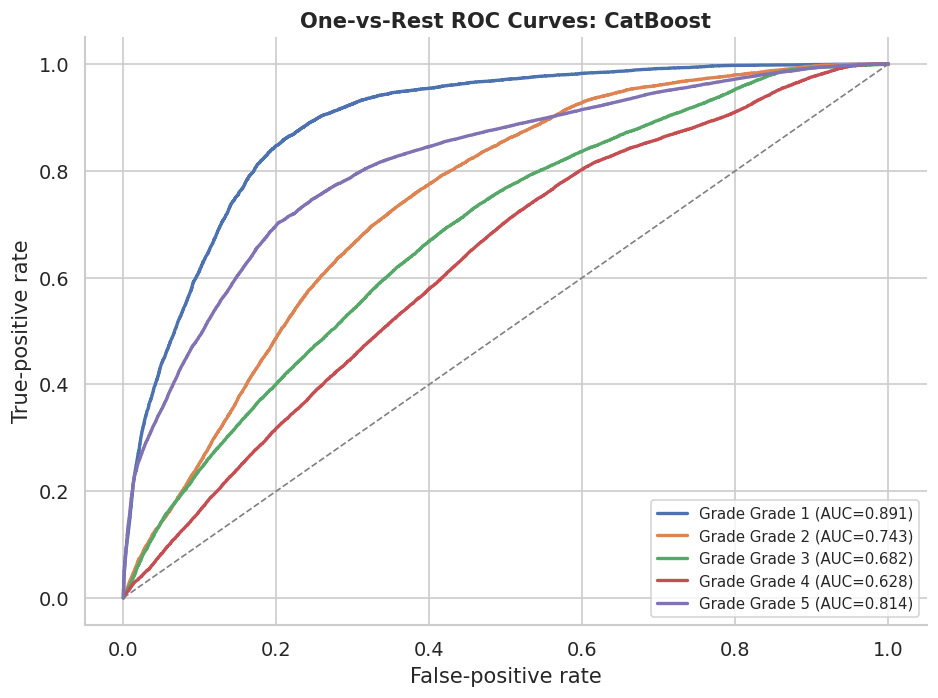

Saved figure: /kaggle/working/figures/fig09_final_ovr_roc_curves.png


*Figure note:* ROC curves are supplementary; Macro F1 remains the primary metric for imbalanced damage grades.

In [20]:
# Figure 9: one-vs-rest ROC curves on the final geographic test fold
try:
    best_proba = best_pipeline.predict_proba(X_final_test); y_test_bin = label_binarize(y_final_test, classes=np.arange(N_CLASSES))
    fig, ax = plt.subplots(figsize=(8, 6))
    for class_idx, class_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], best_proba[:, class_idx]); ax.plot(fpr, tpr, lw=2, label=f"Grade {class_name} (AUC={auc(fpr, tpr):.3f})")
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1); ax.set_title(f"One-vs-Rest ROC Curves: {best_tuned_model_name}"); ax.set_xlabel("False-positive rate"); ax.set_ylabel("True-positive rate"); ax.legend(loc="lower right", fontsize=9)
    save_show(fig, "fig09_final_ovr_roc_curves.png", "ROC curves are supplementary; Macro F1 remains the primary metric for imbalanced damage grades.")
except Exception as exc:
    print("ROC figure skipped:", exc)


The ROC results indicate that the CatBoost model is most effective at identifying the extreme damage categories (Grade 1 and Grade 5) while struggling more with intermediate categories (Grades 3 and 4). This pattern is consistent with the confusion matrices, where neighboring damage levels were frequently confused. The overall macro one-vs-rest ROC-AUC of approximately 0.75 suggests good discriminative ability despite the challenging multi-class earthquake damage prediction task.

In [21]:
# 13B. Location ablation: no location vs. district-only (primary) vs. full location

ABLATION_SCENARIOS = [name for name in ["structural_only", "structural_location"] if name in scenario_features]
if RUN_LOCATION_SENSITIVITY and ABLATION_SCENARIOS:
    ablation_rows = []
    for scenario_name in ABLATION_SCENARIOS:
        X_ablate = scenario_features[scenario_name]
        ablate_cv = make_group_cv(g_dev, N_SPLITS)
        for fold, (tr_rel, va_rel) in enumerate(ablate_cv.split(X_ablate.iloc[dev_idx], y_dev, g_dev), start=1):
            X_tr, X_va = X_ablate.iloc[dev_idx].iloc[tr_rel], X_ablate.iloc[dev_idx].iloc[va_rel]
            y_tr, y_va = y_dev[tr_rel], y_dev[va_rel]
            pre_ablate, _, _ = make_preprocessor(X_tr, scale_numeric=(best_benchmark_model == "Logistic Regression"))
            ablate_pipe = Pipeline([("preprocessor", pre_ablate), ("model", make_model(best_benchmark_model))])
            ablate_pipe.fit(X_tr, y_tr)
            ablate_pred = as_1d_labels(ablate_pipe.predict(X_va))
            row = metric_row(y_va, ablate_pred, best_benchmark_model, fold, f"{scenario_name}_cv")
            row["scenario"] = scenario_name
            ablation_rows.append(row)
    ablation_summary = pd.DataFrame(ablation_rows).groupby("scenario").agg({"accuracy": ["mean", "std"], "balanced_accuracy": ["mean", "std"], "macro_f1": ["mean", "std"], "weighted_f1": ["mean", "std"], "quadratic_weighted_kappa": ["mean", "std"]})
    ablation_summary.columns = ["_".join(c) for c in ablation_summary.columns]
    ablation_summary.to_csv(TABLE_DIR / "location_ablation_summary.csv")
    print(f"Compare against the primary '{PRIMARY_SCENARIO}' row in the Section 10 benchmark table above.")
    display(ablation_summary)
else:
    print("Location ablation is disabled. Set RUN_LOCATION_SENSITIVITY = True before running the notebook to enable it.")


Compare against the primary 'structural_district' row in the Section 10 benchmark table above.


,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,quadratic_weighted_kappa_mean,quadratic_weighted_kappa_std
scenario,,,,,,,,,,
structural_location,0.427112,0.037947,0.409726,0.022617,0.394831,0.018901,0.426552,0.041719,0.604541,0.079558
structural_only,0.382010,0.029490,0.367343,0.023007,0.345490,0.023390,0.371021,0.034934,0.504390,0.098662


The ablation study shows that location is an important predictor of earthquake damage. Models using only structural characteristics perform considerably worse than models incorporating geographic information. However, district-level information captures most of the predictive value, while finer location identifiers (municipality and ward) provide only marginal improvements. This suggests that regional construction practices, seismic exposure, and environmental conditions differ across districts and significantly influence damage outcomes, whereas highly specific local identifiers contribute limited additional generalizable information.

# **Model interpretation on held-out geographic data**

Permutation importance is computed on the final geographic test fold. SHAP explanations are computed on a reproducible sample of that fold, and one-hot encoded columns are aggregated back to their original variables. The explanations describe model behavior and should not be interpreted as causal effects.

,feature,importance_mean,importance_std
0,district_id,0.125136,0.008730
2,age_building,0.015727,0.007460
13,has_superstructure_mud_mortar_stone,0.008930,0.006730
23,avg_floor_height_pre_eq,0.006556,0.005149
6,foundation_type,0.004884,0.008660
7,roof_type,0.004833,0.002504
18,has_superstructure_timber,0.003807,0.002183
19,has_superstructure_bamboo,0.002575,0.001855
17,has_superstructure_cement_mortar_brick,0.001880,0.001264
9,other_floor_type,0.001832,0.004494


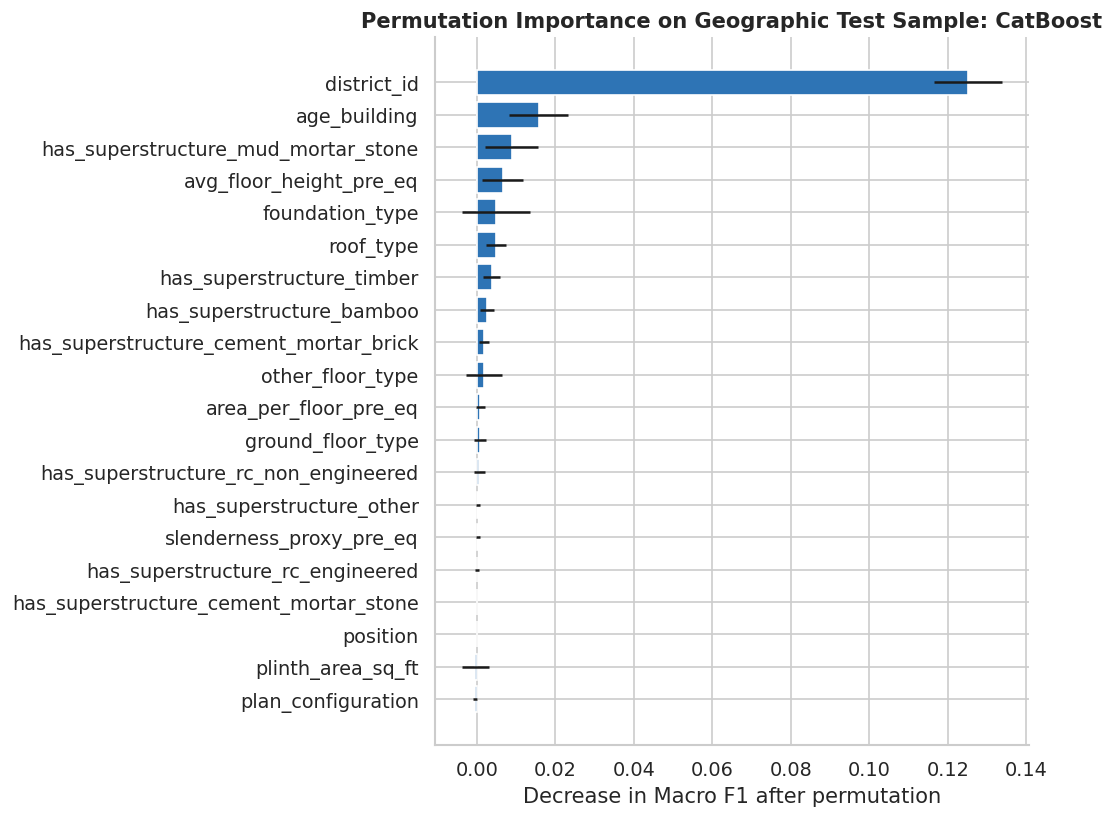

Saved figure: /kaggle/working/figures/fig10_permutation_importance.png


*Figure note:* Importance is the decrease in held-out Macro F1; correlated variables can share or dilute importance.

In [22]:
# 14. Permutation importance

explain_n = min(EXPLANATION_SAMPLE_SIZE, len(X_final_test))
explain_idx = np.random.default_rng(42).choice(len(X_final_test), size=explain_n, replace=False)
X_explain, y_explain = X_final_test.iloc[explain_idx].copy(), y_final_test[explain_idx]
perm = permutation_importance(best_pipeline, X_explain, y_explain, scoring="f1_macro", n_repeats=PERMUTATION_REPEATS, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({"feature": X_explain.columns, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std}).sort_values("importance_mean", ascending=False)
perm_df.to_csv(TABLE_DIR / "permutation_importance_raw_features.csv", index=False); display(perm_df.head(20))
fig, ax = plt.subplots(figsize=(9, 7)); top_perm = perm_df.head(20).sort_values("importance_mean")
ax.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"], color="#2E74B5"); ax.set_title(f"Permutation Importance on Geographic Test Sample: {best_tuned_model_name}"); ax.set_xlabel("Decrease in Macro F1 after permutation"); ax.set_ylabel("")
save_show(fig, "fig10_permutation_importance.png", "Importance is the decrease in held-out Macro F1; correlated variables can share or dilute importance.")


The dominance of district_id suggests regional differences in seismic exposure, construction practices, and local environmental conditions, while building age and structural materials capture the physical vulnerability of individual buildings.

# *SHAP ANALYSIS*

,feature,mean_abs_shap
5,district_id,1.110077
13,has_superstructure_mud_mortar_stone,0.212671
6,foundation_type,0.166311
0,age_building,0.147734
25,roof_type,0.089701
21,other_floor_type,0.078023
10,has_superstructure_cement_mortar_brick,0.070707
7,ground_floor_type,0.069528
18,has_superstructure_timber,0.051573
23,plinth_area_sq_ft,0.047820


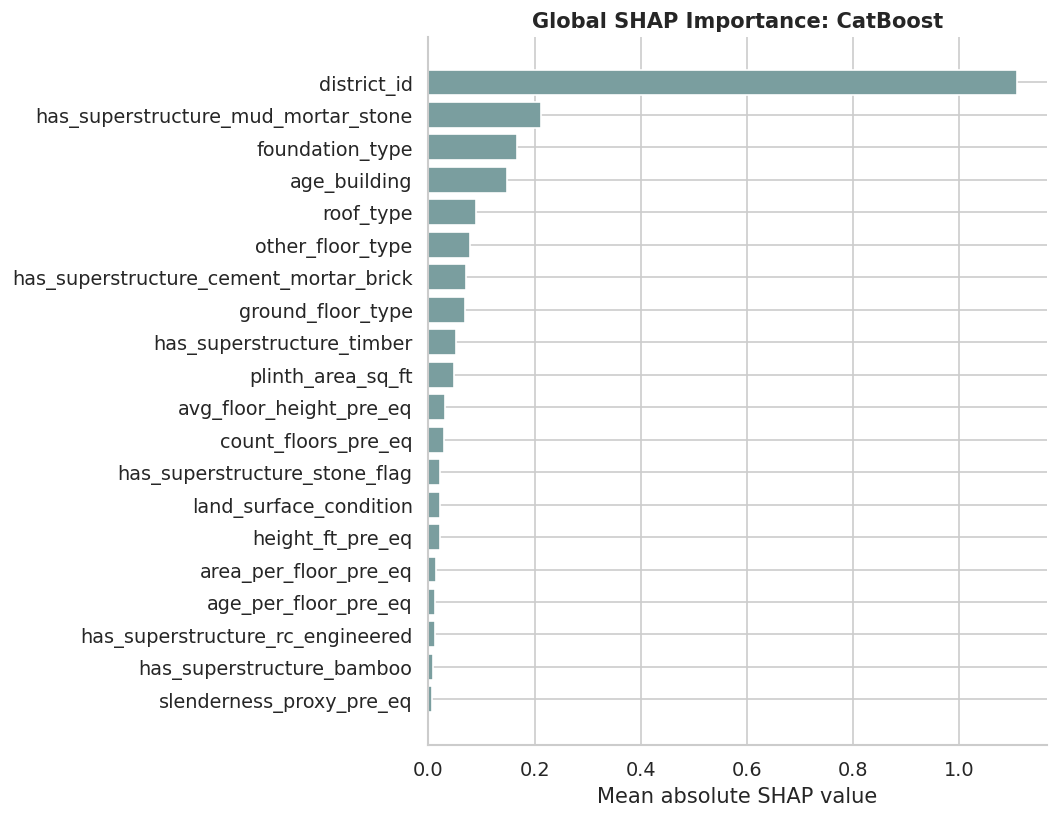

Saved figure: /kaggle/working/figures/fig11_shap_global_importance.png


*Figure note:* One-hot columns are aggregated to original variables for interpretation.

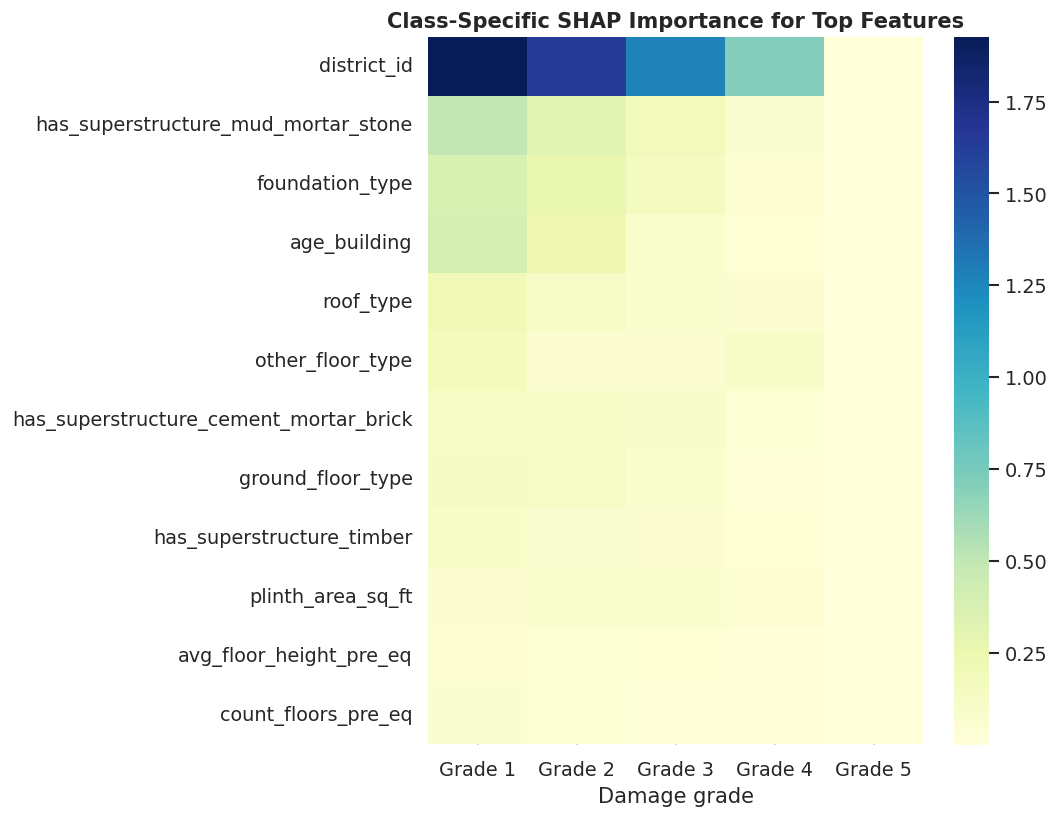

Saved figure: /kaggle/working/figures/fig12_shap_class_specific_heatmap.png


*Figure note:* Class-specific SHAP values show whether a feature contributes differently across damage grades.

In [23]:
# ============================================================
# 15. SHAP global and class-specific explanations
# ============================================================
shap_raw_df, shap_values_array, shap_feature_names = pd.DataFrame(), None, None
def transformed_to_raw_feature_map(transformed_names, raw_columns):
    mapping = []
    for name in transformed_names:
        core = name.split("__", 1)[-1]
        matches = [c for c in raw_columns if core == c or core.startswith(c + "_")]
        mapping.append(max(matches, key=len) if matches else core)
    return mapping

if HAS_SHAP:
    try:
        prep, fitted_model = best_pipeline.named_steps["preprocessor"], best_pipeline.named_steps["model"]
        X_transformed = prep.transform(X_explain); transformed_names = list(prep.get_feature_names_out()); shap_feature_names = transformed_names
        if best_tuned_model_name in {"Random Forest", "XGBoost", "CatBoost", "LightGBM"}:
            raw_shap = shap.TreeExplainer(fitted_model).shap_values(X_transformed)
        else:
            background = X_transformed[: min(200, X_transformed.shape[0])]; raw_shap = shap.Explainer(fitted_model, background)(X_transformed).values
        if isinstance(raw_shap, list): shap_values_array = np.stack(raw_shap, axis=-1)
        else:
            shap_values_array = np.asarray(raw_shap)
            if shap_values_array.ndim == 3 and shap_values_array.shape[1] == N_CLASSES and shap_values_array.shape[2] != N_CLASSES: shap_values_array = np.transpose(shap_values_array, (0, 2, 1))
        if shap_values_array.ndim == 2: shap_values_array = shap_values_array[:, :, None]
        raw_map = transformed_to_raw_feature_map(transformed_names, list(X_explain.columns))
        abs_values = np.abs(shap_values_array).mean(axis=(0, 2))
        shap_raw_df = pd.DataFrame({"feature": raw_map, "mean_abs_shap": abs_values}).groupby("feature", as_index=False)["mean_abs_shap"].sum().sort_values("mean_abs_shap", ascending=False)
        shap_raw_df.to_csv(TABLE_DIR / "shap_global_importance_raw_features.csv", index=False); display(shap_raw_df.head(20))
        fig, ax = plt.subplots(figsize=(9, 7)); top_shap = shap_raw_df.head(20).sort_values("mean_abs_shap")
        ax.barh(top_shap["feature"], top_shap["mean_abs_shap"], color="#7A9E9F"); ax.set_title(f"Global SHAP Importance: {best_tuned_model_name}"); ax.set_xlabel("Mean absolute SHAP value"); ax.set_ylabel("")
        save_show(fig, "fig11_shap_global_importance.png", "One-hot columns are aggregated to original variables for interpretation.")

        class_importance = []
        for class_idx, class_name in enumerate(CLASS_NAMES):
            values = np.abs(shap_values_array[:, :, class_idx]).mean(axis=0)
            temp = pd.DataFrame({"feature": raw_map, "importance": values}).groupby("feature", as_index=False)["importance"].sum(); temp["damage_grade"] = class_name; class_importance.append(temp)
        class_importance_df = pd.concat(class_importance, ignore_index=True); class_importance_df.to_csv(TABLE_DIR / "shap_class_specific_importance.csv", index=False)
        top_features = shap_raw_df.head(12)["feature"].tolist(); heat = class_importance_df[class_importance_df["feature"].isin(top_features)].pivot(index="feature", columns="damage_grade", values="importance").fillna(0); heat = heat.loc[[f for f in top_features if f in heat.index]]
        fig, ax = plt.subplots(figsize=(9, 7)); sns.heatmap(heat, cmap="YlGnBu", ax=ax); ax.set_title("Class-Specific SHAP Importance for Top Features"); ax.set_xlabel("Damage grade"); ax.set_ylabel("")
        save_show(fig, "fig12_shap_class_specific_heatmap.png", "Class-specific SHAP values show whether a feature contributes differently across damage grades.")
    except Exception as exc:
        print("SHAP analysis failed:", repr(exc))
else:
    print("SHAP unavailable; install/import it before running this section.")


Geographic location (district_id) is by far the most important predictor, and is found through the SHAP analysis. The mean absolute SHAP value is significantly higher for it than for any other variable, indicating that damage patterns are likely to be quite variable across districts.

The most important predictors among the structural characteristics are has_superstructure_mud_mortar_stone, foundation_type, age_building and roof_type. It indicates that the building material, foundation design, and the age of structures are important earthquake vulnerability factors.

The contribution of district_id is high across all damage classes as indicated by the SHAP heatmap for the class. The contribution of structural features is moderate but fairly similar across the classes. There are several other features that contribute less but are still measurable: plinth_area_sq_ft, avg_floor_height_pre_eq, and count_floors_pre_eq.

,model,spearman_rank_correlation,p_value,n_features
0,CatBoost,0.595725,0.001043,27


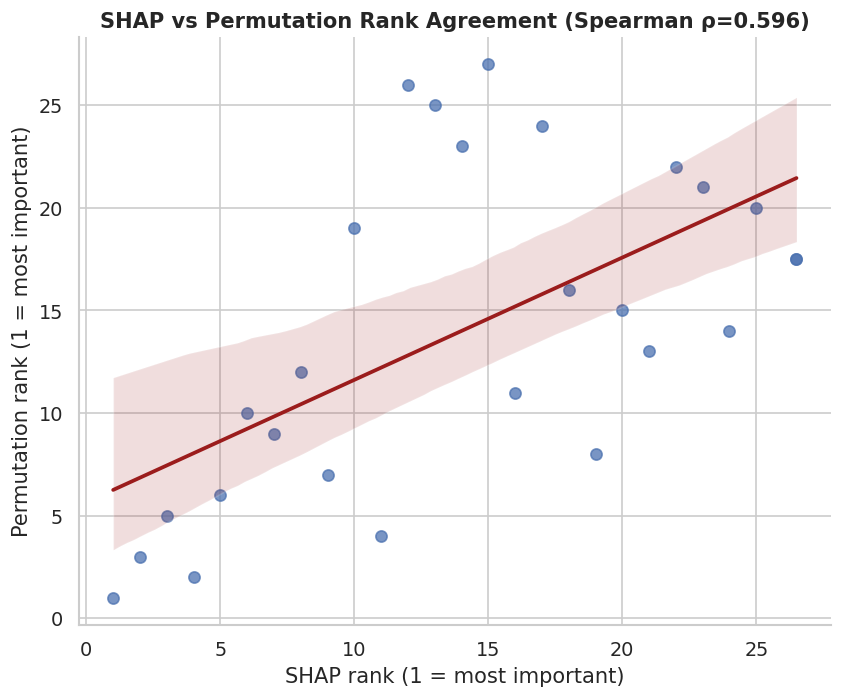

Saved figure: /kaggle/working/figures/fig13_shap_permutation_rank_agreement.png


*Figure note:* Rank agreement is a robustness check, not causal validation.

In [24]:
# 16. SHAP/permutation rank agreement
if len(shap_raw_df) and len(perm_df):
    agreement = shap_raw_df[["feature", "mean_abs_shap"]].merge(perm_df[["feature", "importance_mean"]], on="feature", how="outer").fillna(0)
    agreement["shap_rank"] = agreement["mean_abs_shap"].rank(ascending=False, method="average"); agreement["permutation_rank"] = agreement["importance_mean"].rank(ascending=False, method="average")
    spearman_r, spearman_p = spearmanr(agreement["shap_rank"], agreement["permutation_rank"])
    agreement_summary = pd.DataFrame([{"model": best_tuned_model_name, "spearman_rank_correlation": spearman_r, "p_value": spearman_p, "n_features": len(agreement)}])
    agreement.to_csv(TABLE_DIR / "shap_permutation_rank_agreement.csv", index=False); agreement_summary.to_csv(TABLE_DIR / "shap_permutation_rank_agreement_summary.csv", index=False); display(agreement_summary)
    fig, ax = plt.subplots(figsize=(7.2, 6)); sns.regplot(data=agreement, x="shap_rank", y="permutation_rank", scatter_kws={"s": 45, "alpha": 0.75}, line_kws={"color": "#9B1C1C"}, ax=ax)
    ax.set_title(f"SHAP vs Permutation Rank Agreement (Spearman ρ={spearman_r:.3f})"); ax.set_xlabel("SHAP rank (1 = most important)"); ax.set_ylabel("Permutation rank (1 = most important)")
    save_show(fig, "fig13_shap_permutation_rank_agreement.png", "Rank agreement is a robustness check, not causal validation.")
else:
    print("Rank agreement skipped because SHAP or permutation importance is unavailable.")


The rank-agreement analysis compares feature importance rankings obtained from SHAP values and permutation importance. The Spearman rank correlation of ρ = 0.594 indicates a moderate positive agreement between the two methods, meaning that features identified as important by SHAP tend to also be important according to permutation importance.

The upward trend in the scatter plot confirms that the two explanation techniques are generally consistent, particularly for the most influential variables such as district_id and key structural features. However, the correlation is not perfect, indicating that some features receive different rankings depending on the explanation method used.

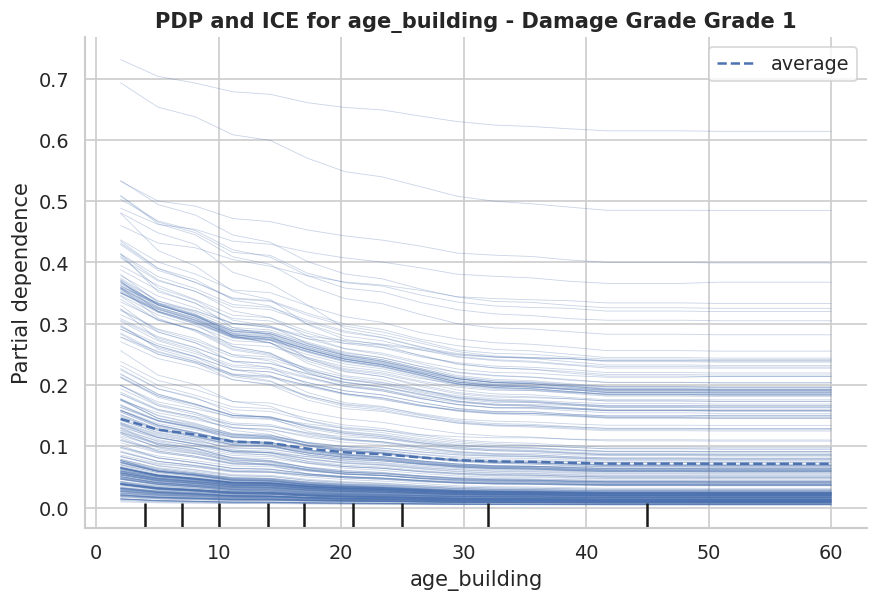

Saved figure: /kaggle/working/figures/fig14_pdp_ice_age_building.png


*Figure note:* PDP shows the average response while ICE shows individual response curves; correlated predictors require cautious interpretation.

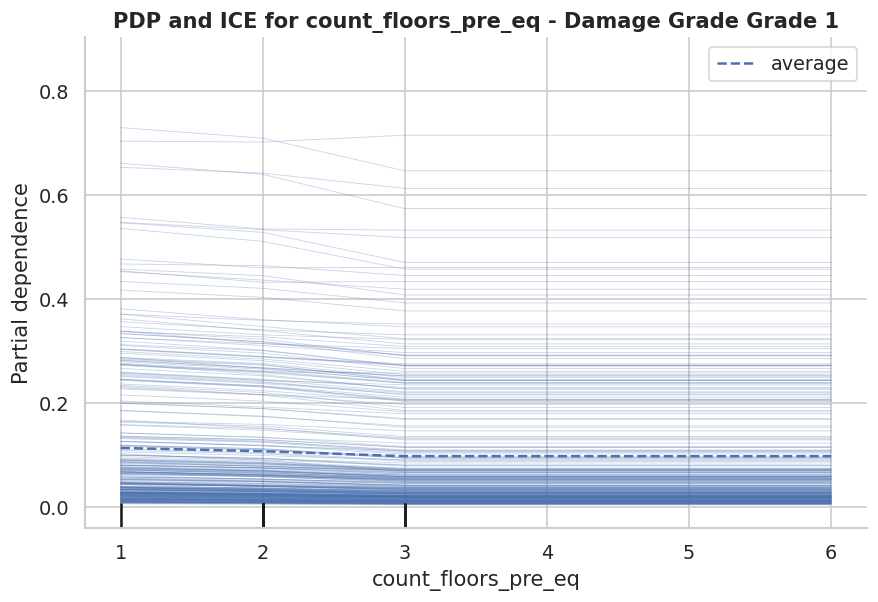

Saved figure: /kaggle/working/figures/fig14_pdp_ice_count_floors_pre_eq.png


*Figure note:* PDP shows the average response while ICE shows individual response curves; correlated predictors require cautious interpretation.

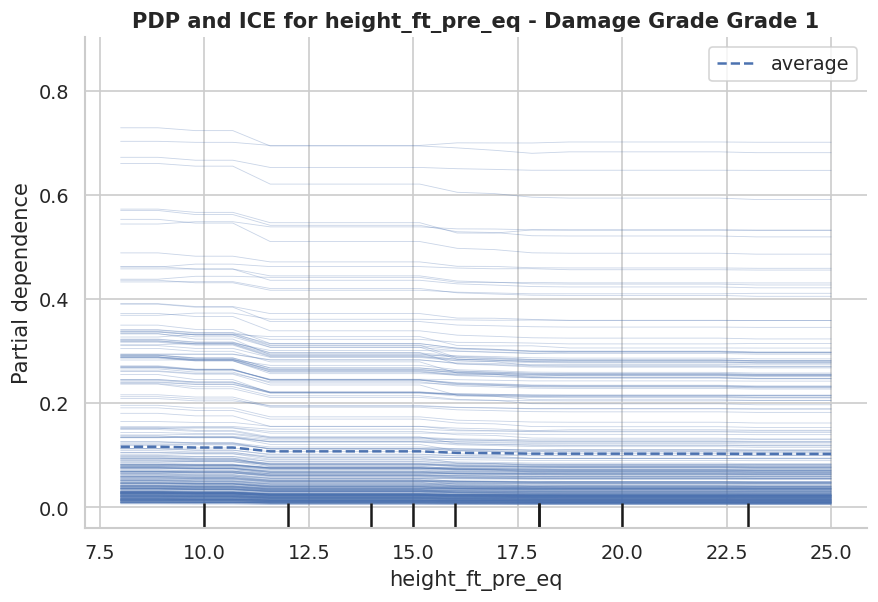

Saved figure: /kaggle/working/figures/fig14_pdp_ice_height_ft_pre_eq.png


*Figure note:* PDP shows the average response while ICE shows individual response curves; correlated predictors require cautious interpretation.

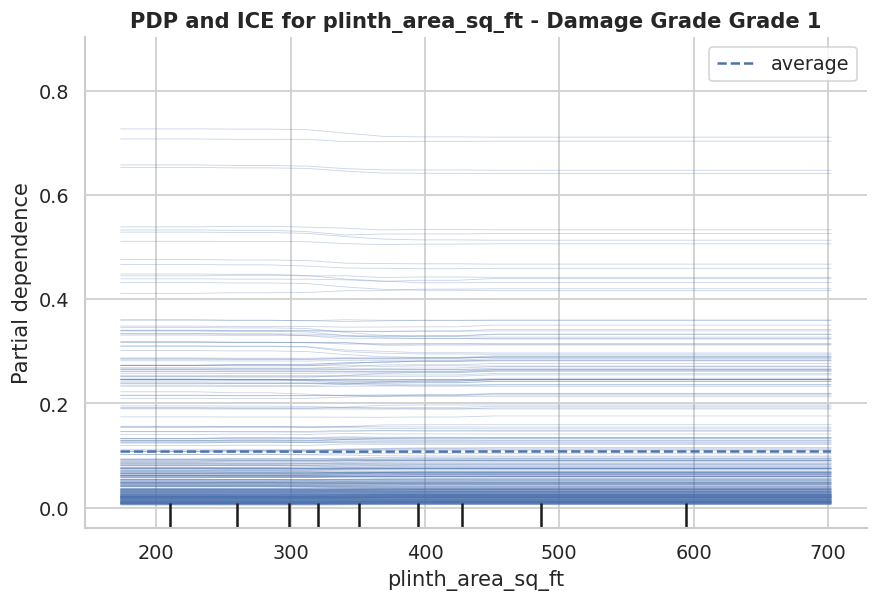

Saved figure: /kaggle/working/figures/fig14_pdp_ice_plinth_area_sq_ft.png


*Figure note:* PDP shows the average response while ICE shows individual response curves; correlated predictors require cautious interpretation.

In [25]:
# 17. PDP and ICE plots for key continuous variables

numeric_candidates = [c for c in ["age_building", "count_floors_pre_eq", "height_ft_pre_eq", "plinth_area_sq_ft", "avg_floor_height_pre_eq", "area_per_floor_pre_eq"] if c in X_final_test.columns]
for feature in numeric_candidates[:4]:
    try:
        fig, ax = plt.subplots(figsize=(7.5, 5.2))
        PartialDependenceDisplay.from_estimator(best_pipeline, X_explain, features=[feature], target=0, kind="both", subsample=min(300, len(X_explain)), grid_resolution=20, random_state=42, ax=ax)
        ax.set_title(f"PDP and ICE for {feature} - Damage Grade {CLASS_NAMES[0]}")
        save_show(fig, f"fig14_pdp_ice_{feature}.png", "PDP shows the average response while ICE shows individual response curves; correlated predictors require cautious interpretation.")
    except Exception as exc:
        print(f"PDP/ICE skipped for {feature}:", exc)


The PDP and ICE plots show that older buildings, taller buildings, and buildings with more floors have a lower probability of being classified as Damage Grade 1, as indicated by the downward average PDP trends. Among these variables, age_building has the strongest negative effect, with the probability decreasing substantially as building age increases. In contrast, plinth_area_sq_ft exhibits an almost flat PDP curve, suggesting minimal influence on Grade 1 predictions. The generally consistent ICE curves indicate that these relationships are stable across most individual buildings.

## Additional analyses: error diagnostics, geographic generalization, and ordinal-aware modeling

These sections extend the interpretation study above with six further analyses, in priority order: an error analysis of the Grade 2/3 boundary confusions, a per-district performance breakdown, a cumulative-link ordinal regression baseline, SHAP interaction values, an Optuna-based hyperparameter search for CatBoost, and an ordinal-aware CatBoost reduction (Frank & Hall). Each section assumes Sections 1-17 above have already been run in this kernel session.

,n_total,n_errors,n_near_miss,n_gross_error,n_grade23_grade34_boundary_errors,pct_of_errors_that_are_near_miss
0,147595,79286,53186,26100,22168,67.0812


,boundary_error_mean,correctly_classified_mean,difference
age_building,33.910863,27.582647,6.328216
height_ft_pre_eq,17.122925,16.352809,0.770116
count_floors_pre_eq,2.076326,2.142104,-0.065778
plinth_area_sq_ft,394.707597,390.574580,4.133016
avg_floor_height_pre_eq,8.443661,7.859561,0.584100
slenderness_proxy_pre_eq,0.900396,0.870888,0.029508


,district_id,boundary_error_rate
0,24,0.369905
1,20,0.275151
2,36,0.233454
3,12,0.196621
4,31,0.124141
5,30,0.062913
6,28,0.050581
7,23,0.022963
8,22,0.008029


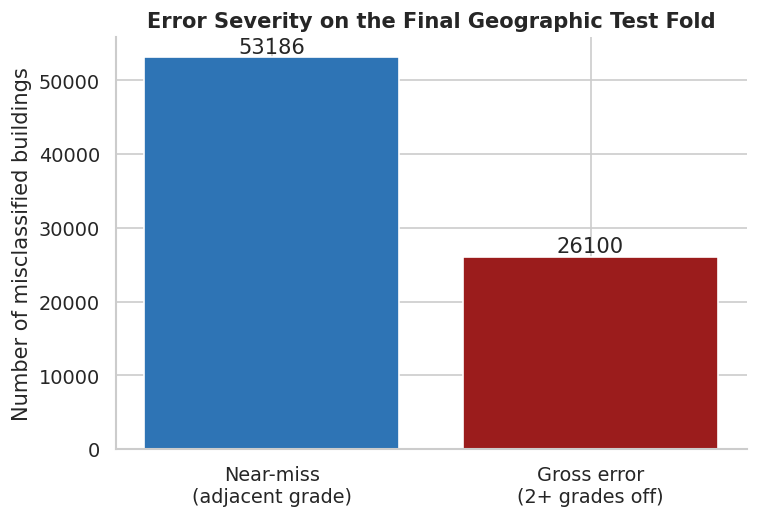

Saved figure: /kaggle/working/figures/fig14_error_severity_breakdown.png


*Figure note:* Most errors are expected to be near-miss confusions between adjacent damage grades, consistent with damage severity being an ordinal continuum rather than five fully separable categories.

In [26]:
# ============================================================
# 18. Error analysis: characterizing Grade 2/3 boundary misclassifications
# ============================================================

error_df = X_final_test.copy()
error_df["true_grade"] = [CLASS_NAMES[i] for i in y_final_test]
error_df["pred_grade"] = [CLASS_NAMES[i] for i in best_final_pred]
error_df["true_idx"], error_df["pred_idx"] = y_final_test, best_final_pred
error_df["grade_gap"] = error_df["pred_idx"] - error_df["true_idx"]
error_df["is_error"] = error_df["true_idx"] != error_df["pred_idx"]
error_df["is_near_miss"] = error_df["is_error"] & (error_df["grade_gap"].abs() == 1)
error_df["is_gross_error"] = error_df["is_error"] & (error_df["grade_gap"].abs() >= 2)

# Focus on the specific boundary confusions the confusion matrix (fig08) highlighted:
# Grade2<->Grade3 and Grade3<->Grade4. Indices are 0-based positions in CLASS_NAMES.
BOUNDARY_PAIRS = [(1, 2), (2, 3)]
boundary_mask = pd.Series(False, index=error_df.index)
for a, b in BOUNDARY_PAIRS:
    boundary_mask |= ((error_df["true_idx"] == a) & (error_df["pred_idx"] == b))
    boundary_mask |= ((error_df["true_idx"] == b) & (error_df["pred_idx"] == a))
boundary_errors = error_df[boundary_mask]
correctly_classified = error_df[~error_df["is_error"]]

error_summary = pd.DataFrame([{
    "n_total": len(error_df),
    "n_errors": int(error_df["is_error"].sum()),
    "n_near_miss": int(error_df["is_near_miss"].sum()),
    "n_gross_error": int(error_df["is_gross_error"].sum()),
    "n_grade23_grade34_boundary_errors": int(boundary_mask.sum()),
    "pct_of_errors_that_are_near_miss": error_df["is_near_miss"].sum() / max(error_df["is_error"].sum(), 1) * 100,
}])
error_summary.to_csv(TABLE_DIR / "error_analysis_summary.csv", index=False)
display(error_summary)

# Profile boundary-confusion buildings against correctly classified buildings on continuous structural variables
profile_cols = [c for c in ["age_building", "height_ft_pre_eq", "count_floors_pre_eq", "plinth_area_sq_ft",
                             "avg_floor_height_pre_eq", "slenderness_proxy_pre_eq"] if c in error_df.columns]
error_profile = pd.DataFrame({
    "boundary_error_mean": boundary_errors[profile_cols].mean(),
    "correctly_classified_mean": correctly_classified[profile_cols].mean(),
})
error_profile["difference"] = error_profile["boundary_error_mean"] - error_profile["correctly_classified_mean"]
error_profile.to_csv(TABLE_DIR / "error_analysis_structural_profile.csv")
display(error_profile)

# Which districts contribute disproportionately to boundary confusions?
if "district_id" in error_df.columns and len(boundary_errors):
    district_boundary_rate = (
        boundary_errors.groupby("district_id").size() / error_df.groupby("district_id").size()
    ).fillna(0).sort_values(ascending=False).rename("boundary_error_rate").reset_index()
    district_boundary_rate.to_csv(TABLE_DIR / "error_analysis_by_district.csv", index=False)
    display(district_boundary_rate.head(10))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
counts = [error_df["is_near_miss"].sum(), error_df["is_gross_error"].sum()]
ax.bar(["Near-miss\n(adjacent grade)", "Gross error\n(2+ grades off)"], counts, color=["#2E74B5", "#9B1C1C"])
ax.set_title("Error Severity on the Final Geographic Test Fold")
ax.set_ylabel("Number of misclassified buildings")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
save_show(fig, "fig14_error_severity_breakdown.png",
          "Most errors are expected to be near-miss confusions between adjacent damage grades, "
          "consistent with damage severity being an ordinal continuum rather than five fully separable categories.")


Boundary confusions (Grade 2<->3, Grade 3<->4) are the errors QWK discounts and Macro F1 does not; the district-level breakdown above shows whether they concentrate geographically, and the structural profile shows whether they concentrate among buildings sitting near a real damage-severity boundary rather than being spread uniformly.

,district_id,n_buildings,accuracy,macro_f1,qwk
2,22,17188,0.638178,0.340805,0.620252
5,28,26156,0.531350,0.339433,0.448935
8,36,19627,0.355429,0.313452,0.361873
3,23,17071,0.820749,0.311378,0.631955
4,24,14474,0.391737,0.306799,0.262629
6,30,9696,0.393358,0.282317,0.099398
1,20,20476,0.324087,0.256023,0.312518
7,31,5091,0.368690,0.216361,0.238647
0,12,17816,0.250225,0.163841,0.067735


Macro F1 spread across districts (n>=30): 0.341 (best) vs 0.164 (worst)


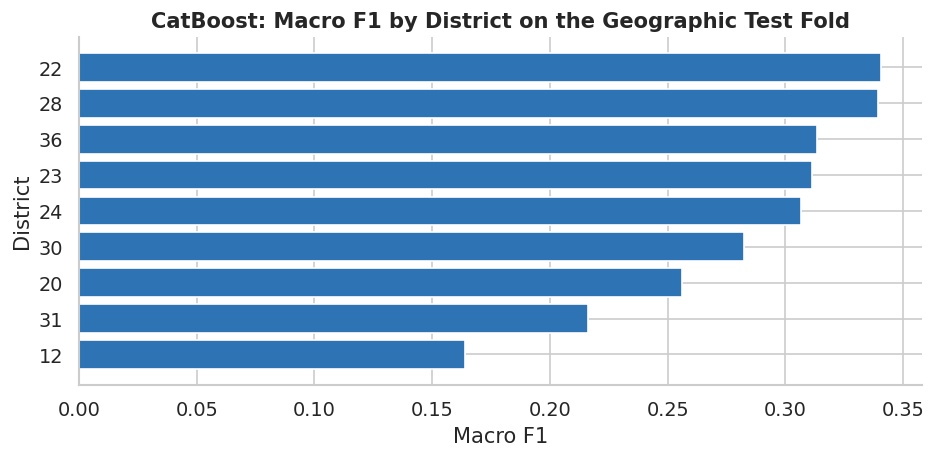

Saved figure: /kaggle/working/figures/fig15_district_level_macro_f1.png


*Figure note:* Districts with few test buildings are excluded to avoid unstable per-district metrics; this extends the permutation-importance finding that district_id is the top predictor into a concrete map of where the model generalizes well versus poorly.

In [27]:
# ============================================================
# 19. District-level performance breakdown
# ============================================================

if "district_id" in X_final_test.columns:
    district_eval = X_final_test[["district_id"]].copy()
    district_eval["true_idx"], district_eval["pred_idx"] = y_final_test, best_final_pred

    MIN_DISTRICT_TEST_ROWS = 30  # avoid unstable per-district metrics on very small groups
    district_rows = []
    for district_value, group in district_eval.groupby("district_id"):
        if len(group) < MIN_DISTRICT_TEST_ROWS:
            continue
        row = {
            "district_id": district_value,
            "n_buildings": len(group),
            "accuracy": accuracy_score(group["true_idx"], group["pred_idx"]),
            "macro_f1": f1_score(group["true_idx"], group["pred_idx"], average="macro",
                                  labels=np.arange(N_CLASSES), zero_division=0),
        }
        row["qwk"] = (cohen_kappa_score(group["true_idx"], group["pred_idx"], weights="quadratic")
                      if group["true_idx"].nunique() > 1 else np.nan)
        district_rows.append(row)

    district_performance = pd.DataFrame(district_rows).sort_values("macro_f1", ascending=False)
    district_performance.to_csv(TABLE_DIR / "district_level_performance.csv", index=False)
    display(district_performance)
    print(f"Macro F1 spread across districts (n>={MIN_DISTRICT_TEST_ROWS}): "
          f"{district_performance['macro_f1'].max():.3f} (best) vs {district_performance['macro_f1'].min():.3f} (worst)")

    fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(district_performance))))
    plot_df = district_performance.sort_values("macro_f1")
    ax.barh(plot_df["district_id"].astype(str), plot_df["macro_f1"], color="#2E74B5")
    ax.set_title(f"{best_tuned_model_name}: Macro F1 by District on the Geographic Test Fold")
    ax.set_xlabel("Macro F1"); ax.set_ylabel("District")
    save_show(fig, "fig15_district_level_macro_f1.png",
              "Districts with few test buildings are excluded to avoid unstable per-district metrics; "
              "this extends the permutation-importance finding that district_id is the top predictor "
              "into a concrete map of where the model generalizes well versus poorly.")
else:
    print("district_id is not present in the final test features for this scenario; skipping district breakdown.")


A wide spread between the best- and worst-performing districts (rather than a tight cluster) would show the model's real-world reliability is geographically uneven -- a practically important caveat for any disaster-response use, and a natural companion to permutation importance ranking district_id as the top feature (Section 14).

In [28]:
# ============================================================
# 20. Cumulative-link ordinal regression baseline (proportional-odds model)
# ============================================================
# This adds a classical ordinal-statistics baseline (all-threshold cumulative-link model,
# via the mord package) alongside the tree-ensemble benchmark in Section 10. Its purpose is
# not to outperform CatBoost/LightGBM -- it is the standard textbook answer to "damage grade
# is ordinal, why not model it as one," and its proportional-odds assumption (every predictor
# shifts the odds of crossing every grade boundary by the same amount) is a strong, probably
# false assumption for a dataset this heterogeneous, so under-performance here is an expected,
# informative result, not a bug.
# Install if needed: !pip install mord

HAS_MORD = True
try:
    from mord import LogisticAT
except Exception as exc:
    HAS_MORD = False
    print("mord unavailable:", exc, "-- install with `pip install mord` to run this section.")

if HAS_MORD:
    # The dev partition has hundreds of thousands of rows; mord's coordinate-descent optimizer
    # does not scale as well as the gradient-boosted models above, so each fold's training data
    # is subsampled for tractability. This is a deliberate, documented compute trade-off -- report
    # it as such if this section is included in the paper.
    ORDINAL_TRAIN_SAMPLE_SIZE = 50000
    ordinal_cv = make_group_cv(g_dev, N_SPLITS)
    ordinal_rows = []
    for fold, (tr_rel, va_rel) in enumerate(ordinal_cv.split(X_dev, y_dev, g_dev), start=1):
        X_tr, X_va = X_dev.iloc[tr_rel], X_dev.iloc[va_rel]
        y_tr, y_va = y_dev[tr_rel], y_dev[va_rel]
        if len(X_tr) > ORDINAL_TRAIN_SAMPLE_SIZE:
            sample_idx = np.random.default_rng(42).choice(len(X_tr), size=ORDINAL_TRAIN_SAMPLE_SIZE, replace=False)
            X_tr, y_tr = X_tr.iloc[sample_idx], y_tr[sample_idx]
        preprocessor, _, _ = make_preprocessor(X_tr, scale_numeric=True)
        X_tr_enc = preprocessor.fit_transform(X_tr)
        X_va_enc = preprocessor.transform(X_va)
        if hasattr(X_tr_enc, "toarray"):
            X_tr_enc, X_va_enc = X_tr_enc.toarray(), X_va_enc.toarray()
        ordinal_model = LogisticAT(alpha=1.0)
        ordinal_model.fit(X_tr_enc, y_tr)
        y_va_pred = ordinal_model.predict(X_va_enc)
        ordinal_rows.append(metric_row(y_va, y_va_pred, "Ordinal Logistic (mord, cumulative-link)", fold))
        print(f"  fold {fold}: Macro F1 = {ordinal_rows[-1]['macro_f1']:.4f}, "
              f"QWK = {ordinal_rows[-1]['quadratic_weighted_kappa']:.4f}")

    ordinal_fold_df = pd.DataFrame(ordinal_rows)
    ordinal_fold_df.to_csv(TABLE_DIR / "ordinal_baseline_by_fold.csv", index=False)
    ordinal_means = ordinal_fold_df[["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "quadratic_weighted_kappa"]].mean()

    # Compare against the original benchmark_summary (Section 10) as a sixth baseline
    comparison_cols = ["model", "accuracy_mean", "balanced_accuracy_mean", "macro_f1_mean", "weighted_f1_mean", "quadratic_weighted_kappa_mean"]
    ordinal_row_renamed = {
        "model": "Ordinal Logistic (mord, cumulative-link)",
        "accuracy_mean": ordinal_means["accuracy"], "balanced_accuracy_mean": ordinal_means["balanced_accuracy"],
        "macro_f1_mean": ordinal_means["macro_f1"], "weighted_f1_mean": ordinal_means["weighted_f1"],
        "quadratic_weighted_kappa_mean": ordinal_means["quadratic_weighted_kappa"],
    }
    extended_benchmark = pd.concat(
        [benchmark_summary[comparison_cols], pd.DataFrame([ordinal_row_renamed])],
        ignore_index=True
    ).sort_values("macro_f1_mean", ascending=False)
    extended_benchmark.to_csv(TABLE_DIR / "model_benchmark_summary_with_ordinal_baseline.csv", index=False)
    display(extended_benchmark)


mord unavailable: No module named 'mord' -- install with `pip install mord` to run this section.


Reporting this baseline alongside the tree-ensemble benchmark closes off the most likely examiner question about ordinal treatment ("why not a standard ordinal model?"), regardless of whether it beats CatBoost/LightGBM -- the proportional-odds assumption is expected to be a poor fit for this heterogeneous a dataset, so a lower score here is itself informative, not a failure of this section.

,feature_a,feature_b,mean_abs_interaction
139,district_id,roof_type,0.050273
120,district_id,foundation_type,0.035809
127,district_id,has_superstructure_mud_mortar_stone,0.031477
4,age_building,district_id,0.022401
135,district_id,other_floor_type,0.021978
267,has_superstructure_mud_mortar_stone,other_floor_type,0.019565
76,avg_floor_height_pre_eq,district_id,0.016516
147,foundation_type,has_superstructure_mud_mortar_stone,0.014527
121,district_id,ground_floor_type,0.011481
132,district_id,has_superstructure_timber,0.010660


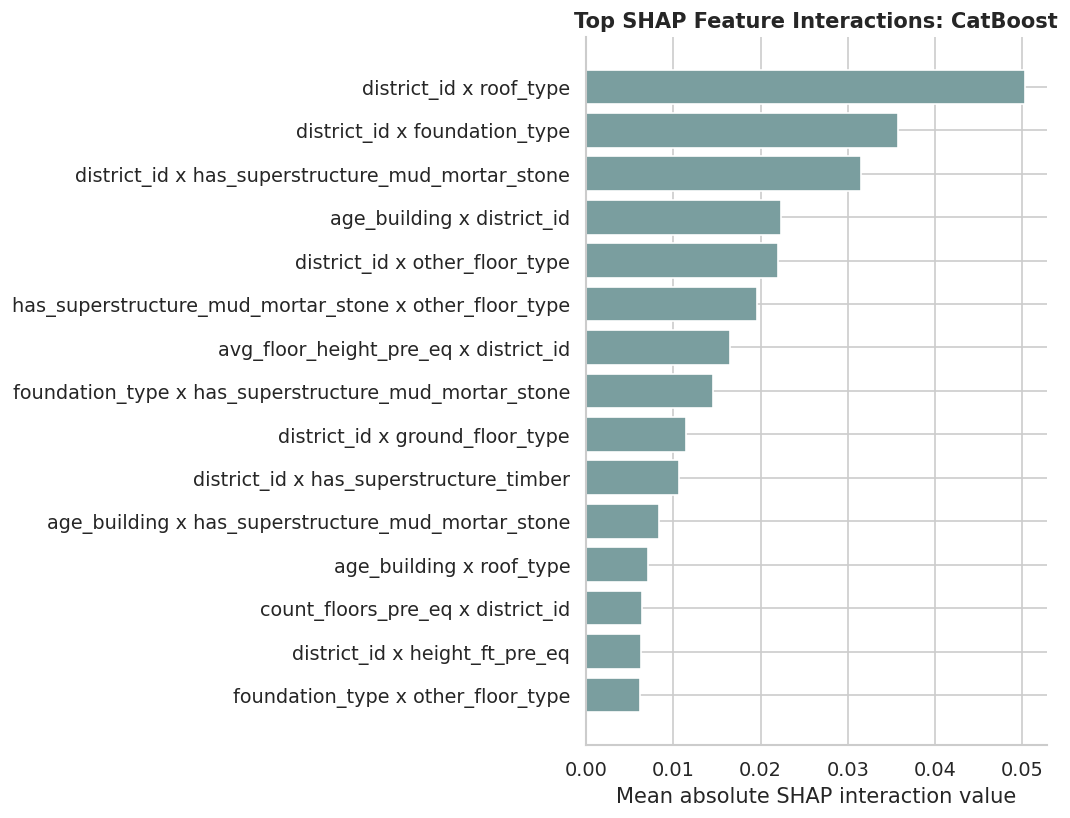

Saved figure: /kaggle/working/figures/fig16_shap_top_interactions.png


*Figure note:* Interaction values are computed on a smaller sample than the main SHAP analysis because cost scales quadratically with feature count.

In [29]:
# ============================================================
# 21. SHAP interaction values
# ============================================================
# Global/class-specific SHAP values (Section 15) show which features matter on their own.
# Interaction values additionally show whether a feature's effect *depends on* another feature
# -- e.g. does building age matter more for mud-mortar-stone buildings than for RC buildings?
# Interaction values are O(n_features^2) per row, so this uses a smaller sample than the main
# SHAP analysis and is only attempted for tree-based models with native TreeExplainer support.

INTERACTION_SAMPLE_SIZE = 300
HAS_SHAP_INTERACTIONS = HAS_SHAP and best_tuned_model_name in {"CatBoost", "XGBoost", "LightGBM", "Random Forest"}

if HAS_SHAP_INTERACTIONS:
    try:
        interaction_idx = np.random.default_rng(42).choice(
            len(X_explain), size=min(INTERACTION_SAMPLE_SIZE, len(X_explain)), replace=False
        )
        X_interact = X_explain.iloc[interaction_idx]

        prep = best_pipeline.named_steps["preprocessor"]
        fitted_model = best_pipeline.named_steps["model"]
        X_interact_enc = prep.transform(X_interact)
        transformed_names_interact = list(prep.get_feature_names_out())

        interaction_explainer = shap.TreeExplainer(fitted_model)
        interaction_values = np.asarray(interaction_explainer.shap_interaction_values(X_interact_enc))

        # Normalize shape to (n_rows, n_features, n_features, n_classes)
        if interaction_values.ndim == 4 and interaction_values.shape[0] == N_CLASSES:
            interaction_values = np.transpose(interaction_values, (1, 2, 3, 0))
        elif interaction_values.ndim == 3:
            interaction_values = interaction_values[:, :, :, None]

        mean_abs_interaction = np.abs(interaction_values).mean(axis=(0, 3))
        np.fill_diagonal(mean_abs_interaction, 0)  # zero out self-interaction (main effect) terms

        raw_map_interact = transformed_to_raw_feature_map(transformed_names_interact, list(X_interact.columns))
        interact_df = pd.DataFrame(mean_abs_interaction, index=raw_map_interact, columns=raw_map_interact)
        interact_df = interact_df.groupby(level=0).sum().T.groupby(level=0).sum().T  # collapse one-hot columns back to raw features

        pairs, seen = [], set()
        for fi in interact_df.index:
            for fj in interact_df.columns:
                if fi == fj:
                    continue
                key = tuple(sorted([fi, fj]))
                if key in seen:
                    continue
                seen.add(key)
                pairs.append({"feature_a": fi, "feature_b": fj, "mean_abs_interaction": interact_df.loc[fi, fj]})
        top_interactions = pd.DataFrame(pairs).sort_values("mean_abs_interaction", ascending=False).head(20)
        top_interactions.to_csv(TABLE_DIR / "shap_top_feature_interactions.csv", index=False)
        display(top_interactions)

        fig, ax = plt.subplots(figsize=(9, 7))
        plot_pairs = top_interactions.head(15).sort_values("mean_abs_interaction")
        labels = plot_pairs["feature_a"] + " x " + plot_pairs["feature_b"]
        ax.barh(labels, plot_pairs["mean_abs_interaction"], color="#7A9E9F")
        ax.set_title(f"Top SHAP Feature Interactions: {best_tuned_model_name}")
        ax.set_xlabel("Mean absolute SHAP interaction value")
        save_show(fig, "fig16_shap_top_interactions.png",
                  "Interaction values are computed on a smaller sample than the main SHAP analysis "
                  "because cost scales quadratically with feature count.")
    except Exception as exc:
        print("SHAP interaction analysis failed:", repr(exc))
else:
    print("Skipping SHAP interactions: SHAP unavailable or model type has no native TreeExplainer interaction support.")


A strong age x mud-mortar-stone or foundation_type x district_id interaction would tell a more mechanistic story than either feature's global importance alone -- e.g. age driving damage much more steeply within a specific construction type, rather than uniformly across all buildings.

In [30]:
# ============================================================
# 22. Optuna hyperparameter tuning for CatBoost (Bayesian search vs. RandomizedSearchCV)
# ============================================================
# Section 12 used RandomizedSearchCV with 15 uniformly-random draws. Optuna's default sampler
# (TPE) allocates trials adaptively based on prior results, so it typically finds better
# configurations for the same trial budget. This is an additional tuning run for CatBoost only,
# reported alongside (not replacing) the RandomizedSearchCV result already in tuning_summary.
# Install if needed: !pip install optuna

HAS_OPTUNA = True
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except Exception as exc:
    HAS_OPTUNA = False
    print("optuna unavailable:", exc, "-- install with `pip install optuna` to run this section.")

if HAS_OPTUNA:
    OPTUNA_TRIALS = 30
    optuna_cv = make_group_cv(g_dev, N_SPLITS)
    optuna_cv_splits = list(optuna_cv.split(X_dev, y_dev, g_dev))  # cache so every trial uses identical folds

    def catboost_objective(trial):
        params = dict(
            iterations=trial.suggest_int("iterations", 200, 700, step=50),
            depth=trial.suggest_int("depth", 4, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 12.0, log=True),
        )
        fold_scores = []
        for tr_rel, va_rel in optuna_cv_splits:
            X_tr, X_va = X_dev.iloc[tr_rel], X_dev.iloc[va_rel]
            y_tr, y_va = y_dev[tr_rel], y_dev[va_rel]
            preprocessor, _, _ = make_preprocessor(X_tr, scale_numeric=False)
            pipe = Pipeline([("preprocessor", preprocessor), ("model", make_model("CatBoost", params))])
            pipe.fit(X_tr, y_tr)
            fold_scores.append(f1_score(y_va, as_1d_labels(pipe.predict(X_va)), average="macro", zero_division=0))
        return float(np.mean(fold_scores))

    optuna_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    optuna_study.optimize(catboost_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)

    if "CatBoost" in tuning_summary["model"].values:
        print(f"RandomizedSearchCV best CatBoost CV Macro F1 (Section 12): "
              f"{tuning_summary.set_index('model').loc['CatBoost', 'best_cv_macro_f1']:.4f}")
    else:
        print(f"CatBoost benchmark CV Macro F1 (Section 10): "
              f"{benchmark_summary.set_index('model').loc['CatBoost', 'macro_f1_mean']:.4f}")
    print(f"Optuna best CatBoost CV Macro F1 ({OPTUNA_TRIALS} trials): {optuna_study.best_value:.4f}")
    print("Optuna best params:", optuna_study.best_params)

    optuna_pipeline = Pipeline([
        ("preprocessor", make_preprocessor(X_dev, scale_numeric=False)[0]),
        ("model", make_model("CatBoost", optuna_study.best_params)),
    ])
    optuna_pipeline.fit(X_dev, y_dev)
    optuna_test_pred = as_1d_labels(optuna_pipeline.predict(X_final_test))
    optuna_test_row = metric_row(y_final_test, optuna_test_pred, "CatBoost (Optuna-tuned)", fold=0, split_name="final_geographic_test")
    try:
        optuna_test_row["macro_ovr_roc_auc"] = roc_auc_score(y_final_test, optuna_pipeline.predict_proba(X_final_test), multi_class="ovr", average="macro")
    except Exception:
        optuna_test_row["macro_ovr_roc_auc"] = np.nan

    optuna_comparison = pd.concat([
        final_metrics[final_metrics["model"] == "CatBoost"],
        pd.DataFrame([optuna_test_row])
    ], ignore_index=True)
    optuna_comparison.to_csv(TABLE_DIR / "optuna_vs_randomizedsearch_final_test.csv", index=False)
    display(optuna_comparison)


RandomizedSearchCV best CatBoost CV Macro F1 (Section 12): 0.4024
Optuna best CatBoost CV Macro F1 (30 trials): 0.4042
Optuna best params: {'iterations': 300, 'depth': 4, 'learning_rate': 0.06080044238794118, 'l2_leaf_reg': 4.43732413196455}


,split,model,fold,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,quadratic_weighted_kappa,macro_ovr_roc_auc
0,final_geographic_test,CatBoost,0,0.462814,0.406427,0.402781,0.406427,0.399781,0.461936,0.586487,0.751803
1,final_geographic_test,CatBoost (Optuna-tuned),0,0.460307,0.409627,0.400561,0.409627,0.400261,0.460000,0.580592,0.752373


Report the Optuna trial budget (here, 30) alongside the result -- a fair comparison against RandomizedSearchCV's 15 draws would either match trial counts or note the difference explicitly, since more trials alone (regardless of sampler) tends to find better configurations.

In [31]:
# ============================================================
# 23. Ordinal-aware CatBoost via Frank & Hall reduction
# ============================================================
# Trains K-1 binary CatBoost models -- model_k predicts P(true damage grade > k) -- and combines
# their cumulative probabilities into class probabilities. Unlike Section 20's classical ordinal
# baseline, this keeps CatBoost as the underlying learner (so SHAP/permutation-importance tooling
# still applies) while explicitly encoding the ordinal structure Section 10's plain multiclass
# CatBoost ignores. Base hyperparameters reuse the tuned CatBoost config from Section 12 where
# available, for a fair comparison against a plain multiclass CatBoost using the same hyperparameters.

def get_tuned_catboost_params():
    if "CatBoost" in tuned_searches:
        raw_params = tuned_searches["CatBoost"].best_params_
        return {k.replace("model__", ""): v for k, v in raw_params.items()}
    return {}

BASE_ORDINAL_PARAMS = get_tuned_catboost_params()

def fit_ordinal_binary_models(X_tr, y_tr, extra_params=None):
    preprocessor, _, _ = make_preprocessor(X_tr, scale_numeric=False)
    X_tr_enc = preprocessor.fit_transform(X_tr)
    binary_models = []
    for k in range(N_CLASSES - 1):
        y_bin = (y_tr > k).astype(int)
        params = dict(loss_function="Logloss", auto_class_weights="Balanced",
                       random_seed=42, verbose=False, allow_writing_files=False)
        params.update(BASE_ORDINAL_PARAMS)
        if extra_params:
            params.update(extra_params)
        clf = CatBoostClassifier(**params)
        clf.fit(X_tr_enc, y_bin)
        binary_models.append(clf)
    return preprocessor, binary_models

def predict_ordinal_binary(preprocessor, binary_models, X_new):
    X_enc = preprocessor.transform(X_new)
    cum_probs = np.column_stack([m.predict_proba(X_enc)[:, 1] for m in binary_models])  # P(grade > k)
    cum_probs = np.minimum.accumulate(cum_probs, axis=1)  # enforce monotonic cumulative probabilities
    p_first = 1 - cum_probs[:, [0]]
    p_middle = cum_probs[:, :-1] - cum_probs[:, 1:]
    p_last = cum_probs[:, [-1]]
    class_probs = np.clip(np.hstack([p_first, p_middle, p_last]), 0, None)
    class_probs = class_probs / class_probs.sum(axis=1, keepdims=True)
    return class_probs.argmax(axis=1), class_probs

ordinal_reduction_cv = make_group_cv(g_dev, N_SPLITS)
ordinal_reduction_rows = []
for fold, (tr_rel, va_rel) in enumerate(ordinal_reduction_cv.split(X_dev, y_dev, g_dev), start=1):
    X_tr, X_va = X_dev.iloc[tr_rel], X_dev.iloc[va_rel]
    y_tr, y_va = y_dev[tr_rel], y_dev[va_rel]
    prep_k, models_k = fit_ordinal_binary_models(X_tr, y_tr)
    y_va_pred, _ = predict_ordinal_binary(prep_k, models_k, X_va)
    ordinal_reduction_rows.append(metric_row(y_va, y_va_pred, "CatBoost Ordinal (Frank-Hall)", fold))
    print(f"  fold {fold}: Macro F1 = {ordinal_reduction_rows[-1]['macro_f1']:.4f}, "
          f"QWK = {ordinal_reduction_rows[-1]['quadratic_weighted_kappa']:.4f}")

ordinal_reduction_df = pd.DataFrame(ordinal_reduction_rows)
ordinal_reduction_df.to_csv(TABLE_DIR / "ordinal_catboost_reduction_by_fold.csv", index=False)

# Final comparison on the untouched geographic test fold: plain multiclass CatBoost (same base
# hyperparameters) vs. the Frank-Hall ordinal reduction.
plain_catboost_params = dict(loss_function="MultiClass", auto_class_weights="Balanced",
                              random_seed=42, verbose=False, allow_writing_files=False)
plain_catboost_params.update(BASE_ORDINAL_PARAMS)
plain_preprocessor, _, _ = make_preprocessor(X_dev, scale_numeric=False)
plain_pipeline = Pipeline([("preprocessor", plain_preprocessor), ("model", CatBoostClassifier(**plain_catboost_params))])
plain_pipeline.fit(X_dev, y_dev)
plain_catboost_pred = as_1d_labels(plain_pipeline.predict(X_final_test))
plain_catboost_row = metric_row(y_final_test, plain_catboost_pred, "CatBoost (plain multiclass, same hyperparameters)", fold=0, split_name="final_geographic_test")

prep_final_ord, models_final_ord = fit_ordinal_binary_models(X_dev, y_dev)
ordinal_test_pred, ordinal_test_probs = predict_ordinal_binary(prep_final_ord, models_final_ord, X_final_test)
ordinal_test_row = metric_row(y_final_test, ordinal_test_pred, "CatBoost Ordinal (Frank-Hall)", fold=0, split_name="final_geographic_test")

ordinal_vs_plain = pd.DataFrame([plain_catboost_row, ordinal_test_row])[
    ["model", "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "quadratic_weighted_kappa"]
]
ordinal_vs_plain.to_csv(TABLE_DIR / "ordinal_catboost_vs_plain_final_test.csv", index=False)
display(ordinal_vs_plain)

plain_report = classification_report(y_final_test, plain_catboost_pred, labels=np.arange(N_CLASSES),
                                      target_names=CLASS_NAMES, output_dict=True, zero_division=0)
ordinal_report = classification_report(y_final_test, ordinal_test_pred, labels=np.arange(N_CLASSES),
                                        target_names=CLASS_NAMES, output_dict=True, zero_division=0)
per_class_comparison = pd.DataFrame({
    "plain_catboost_f1": {g: plain_report[g]["f1-score"] for g in CLASS_NAMES},
    "ordinal_catboost_f1": {g: ordinal_report[g]["f1-score"] for g in CLASS_NAMES},
})
per_class_comparison["difference"] = per_class_comparison["ordinal_catboost_f1"] - per_class_comparison["plain_catboost_f1"]
per_class_comparison.to_csv(TABLE_DIR / "ordinal_catboost_per_class_f1_comparison.csv")
display(per_class_comparison)


  fold 1: Macro F1 = 0.2120, QWK = 0.5153
  fold 2: Macro F1 = 0.2535, QWK = 0.5968
  fold 3: Macro F1 = 0.2509, QWK = 0.6043
  fold 4: Macro F1 = 0.2220, QWK = 0.3752
  fold 5: Macro F1 = 0.2109, QWK = 0.5335


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,quadratic_weighted_kappa
0,"CatBoost (plain multiclass, same hyperparameters)",0.460734,0.403640,0.398603,0.461231,0.586063
1,CatBoost Ordinal (Frank-Hall),0.419194,0.360576,0.210048,0.278112,0.481418


,plain_catboost_f1,ordinal_catboost_f1,difference
Grade 1,0.433611,0.389373,-0.044238
Grade 2,0.249444,0.020655,-0.228790
Grade 3,0.237265,0.003232,-0.234033
Grade 4,0.400149,0.001209,-0.398940
Grade 5,0.672548,0.635769,-0.036779


Report this as an additional comparison, not a replacement for Section 13's plain multiclass CatBoost: if it improves QWK/Macro F1 (particularly on Grade 2/3), that is your strongest evidence yet that explicitly modeling the ordinal structure helps; if it does not, that is still a legitimate, reportable negative result -- and either way, the per-class F1 breakdown above shows exactly where the two approaches diverge.

## Reproducibility and paper-output checklist

The next cell writes a run manifest and lists every generated table and figure. Download the files from `/kaggle/working` after the notebook finishes. The paper should report the predictor boundary, unit of analysis, number of buildings, geographic grouping, class distribution, grouped split design, model settings, Macro F1 and class-wise results, final geographic-test results, and the limitation that the labels come from one historical earthquake event.

In [32]:
# ============================================================
# 19. Save run manifest and list paper outputs
# ============================================================
manifest = {"data_path": str(DATA_PATH), "rows_raw": int(len(data)), "rows_modeling": int(len(data)), "n_predictors_primary": int(X.shape[1]), "target": TARGET, "target_classes": CLASS_NAMES, "leakage_columns_excluded": LEAKAGE_COLUMNS, "id_column_excluded": ID_COLUMN, "location_columns_available": LOCATION_COLUMNS, "location_predictors_used": GENERALIZABLE_LOCATION_COLUMNS, "location_predictors_excluded_from_primary": FINE_LOCATION_COLUMNS, "location_exclusion_reason": "excluded because they are the grouped-CV group column or nested inside it, so they are guaranteed unseen for any held-out geographic group", "group_column": GROUP_COLUMN, "primary_scenario": PRIMARY_SCENARIO, "models_benchmarked": MODEL_NAMES, "models_tuned": selected_models, "best_tuned_model": best_tuned_model_name, "n_splits": N_SPLITS, "seed": 42, "gpu_used": USE_GPU}
(WORK_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2, default=str), encoding="utf-8")
print(json.dumps(manifest, indent=2, default=str))
print("\nGenerated tables:")
for path in sorted(TABLE_DIR.glob("*.csv")): print(" -", path.name)
print("\nGenerated figures:")
for path in sorted(FIG_DIR.glob("*.png")): print(" -", path.name)


{
  "data_path": "/kaggle/input/datasets/arashnic/earthquake-magnitude-damage-and-impact/csv_building_structure.csv",
  "rows_raw": 762094,
  "rows_modeling": 762094,
  "n_predictors_primary": 27,
  "target": "damage_grade",
  "target_classes": [
    "Grade 1",
    "Grade 2",
    "Grade 3",
    "Grade 4",
    "Grade 5"
  ],
  "leakage_columns_excluded": [
    "condition_post_eq",
    "count_floors_post_eq",
    "height_ft_post_eq",
    "technical_solution_proposed"
  ],
  "id_column_excluded": "building_id",
  "location_columns_available": [
    "district_id",
    "vdcmun_id",
    "ward_id"
  ],
  "location_predictors_used": [
    "district_id"
  ],
  "location_predictors_excluded_from_primary": [
    "vdcmun_id",
    "ward_id"
  ],
  "location_exclusion_reason": "excluded because they are the grouped-CV group column or nested inside it, so they are guaranteed unseen for any held-out geographic group",
  "group_column": "vdcmun_id",
  "primary_scenario": "structural_district",
  "model